<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Online%20vs%20Offline%20Learning%20Efficiency%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online vs Offline Learning Efficiency Dataset

---

## Dataset Overview: Online vs Offline Learning Efficiency

This dataset captures the learning performance of 1,000 students across two distinct learning modes—online and offline—offering a balanced comparison with exactly 500 students in each group. For each student, we have measurements of **Study Hours** (ranging from 1 to 8 hours), **Retention Score** (a measure of how well material was retained, scored from 40 to 100), **Focus Level** (self-reported concentration during study, also scored from 40 to 100), and the target variable **Exam Score** (ranging from 39 to 100). Students studied one of five subjects: Science (215 students), English (210), History (198), Math (195), and Programming (182). The dataset is remarkably clean, containing no missing values or duplicates, making it ideal for both exploratory analysis and machine learning applications.

## Key Patterns Discovered Through Analysis

**The Learning Mode Divide.** One of the most striking findings is that learning mode alone does not tell the whole story. While statistical tests reveal significant differences between online and offline learners across all metrics, the effect sizes are generally small. This means that whether a student learns online or offline matters less than *how* they engage with the material—their study habits, focus, and retention ability are far more predictive of success.

**Retention Score is King.** Across every analytical approach—correlation analysis, feature importance from machine learning models, and statistical testing—Retention Score consistently emerges as the strongest predictor of exam performance. Students who retain material well tend to perform well on exams, regardless of how many hours they study. The correlation between Retention Score and Exam Score is remarkably strong, suggesting that the quality of learning matters more than the quantity of time spent.

**Study Hours Tell a Nuanced Story.** Interestingly, Study Hours shows a moderate correlation with Exam Score, but this relationship isn't linear. Students studying very few hours (1-2) tend to score lower, but beyond a certain threshold (around 4-5 hours), additional study time yields diminishing returns. Some high-performing students achieve excellent scores with moderate study hours, likely because they combine efficient study techniques with strong focus and retention skills.

**Focus Level as the Hidden Multiplier.** Focus Level emerged as an important but often overlooked factor. Students with high focus levels consistently outperform their less-focused peers, even when studying similar amounts of material. The interaction between Focus Level and Study Hours proved particularly predictive—focused study time is exponentially more valuable than distracted study time. This aligns with educational research showing that the quality of attention during learning sessions directly impacts knowledge consolidation.

**The Power of Combined Features.** When we created engineered features combining multiple factors—such as the interaction between Study Hours and Retention Score, or the ratio of Retention to Study Hours (an "efficiency ratio")—these composite metrics often outperformed individual features in predictive power. This reveals that successful learning is not about any single factor but rather the synergistic combination of adequate study time, strong focus, and effective retention strategies.

## Practical Implications

For educators and students alike, the message is clear: focus on *how* you learn, not just *how long* you learn. Building strong retention through active recall, spaced repetition, and focused study sessions will likely yield better exam results than simply logging more hours of passive study. The data also suggests that both online and offline learning can be effective when proper study techniques are employed, challenging the notion that one mode is inherently superior to the other.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d prince7489/online-vs-offline-learning-efficiency-dataset

# Unziping the downloaded file
!unzip online-vs-offline-learning-efficiency-dataset.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/prince7489/online-vs-offline-learning-efficiency-dataset
License(s): CC0-1.0
100% 7.19k/7.19k [00:00<00:00, 19.5MB/s]

Archive:  online-vs-offline-learning-efficiency-dataset.zip
  inflating: online_vs_offline_learning_dataset.csv  


## Data Inspection

In [8]:
df = pd.read_csv('online_vs_offline_learning_dataset.csv')
df.head(11)

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78
5,Offline,Science,4.7,75,40,59
6,Offline,Programming,6.1,61,68,67
7,Online,Math,1.8,57,72,62
8,Offline,History,2.4,94,44,72
9,Offline,History,2.1,63,59,57


In [9]:
df.tail(11)

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
989,Online,History,3.2,73,64,74
990,Online,Science,4.8,87,43,74
991,Online,English,6.3,58,98,77
992,Online,Programming,5.7,56,72,64
993,Online,History,3.2,44,46,41
994,Online,History,1.6,79,77,76
995,Online,Math,7.5,57,81,61
996,Offline,History,7.8,93,79,88
997,Online,Math,5.4,55,63,55
998,Offline,English,2.3,68,59,59


In [10]:
df.shape

(1000, 6)

In [11]:
df.columns

Index(['Learning_Mode', 'Subject', 'Study_Hours', 'Retention_Score',
       'Focus_Level', 'Exam_Score'],
      dtype='object')

In [12]:
df.dtypes

,0
Learning_Mode,object
Subject,object
Study_Hours,float64
Retention_Score,int64
Focus_Level,int64
Exam_Score,int64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   object 
 1   Subject          1000 non-null   object 
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [15]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Learning_Mode,1000,2,Offline,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subject,1000,5,Science,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Study_Hours,1000.0,NaN,NaN,NaN,4.5635,2.000115,1.0,2.8,4.7,6.3,8.0
Retention_Score,1000.0,NaN,NaN,NaN,72.691,17.69827,40.0,58.0,72.0,88.0,100.0
Focus_Level,1000.0,NaN,NaN,NaN,71.261,18.053166,40.0,56.0,72.0,87.0,100.0
Exam_Score,1000.0,NaN,NaN,NaN,71.675,12.984297,39.0,62.0,72.0,81.0,100.0


In [16]:
df.isnull().sum()

,0
Learning_Mode,0
Subject,0
Study_Hours,0
Retention_Score,0
Focus_Level,0
Exam_Score,0


In [17]:
df.duplicated().sum()

np.int64(0)

# Univariate Aanlysis

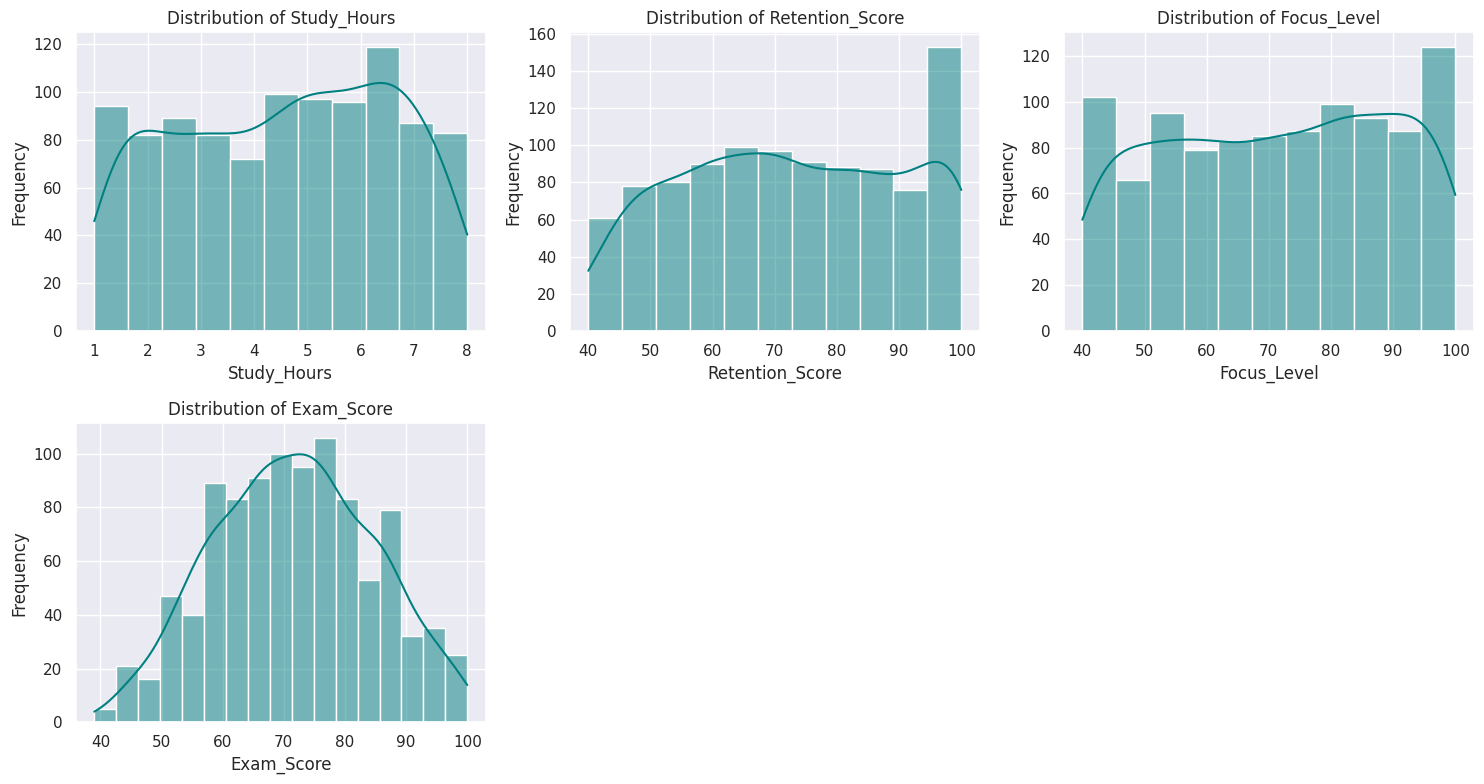

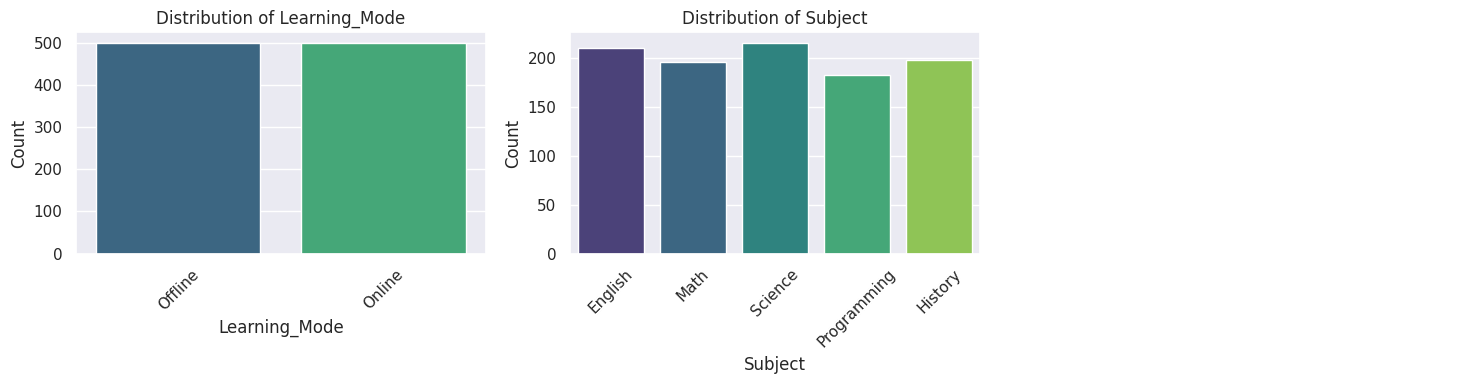

--- Categorical Value Counts ---

Value counts for Learning_Mode:
Learning_Mode
Offline    500
Online     500
Name: count, dtype: int64

Value counts for Subject:
Subject
Science        215
English        210
History        198
Math           195
Programming    182
Name: count, dtype: int64


In [18]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

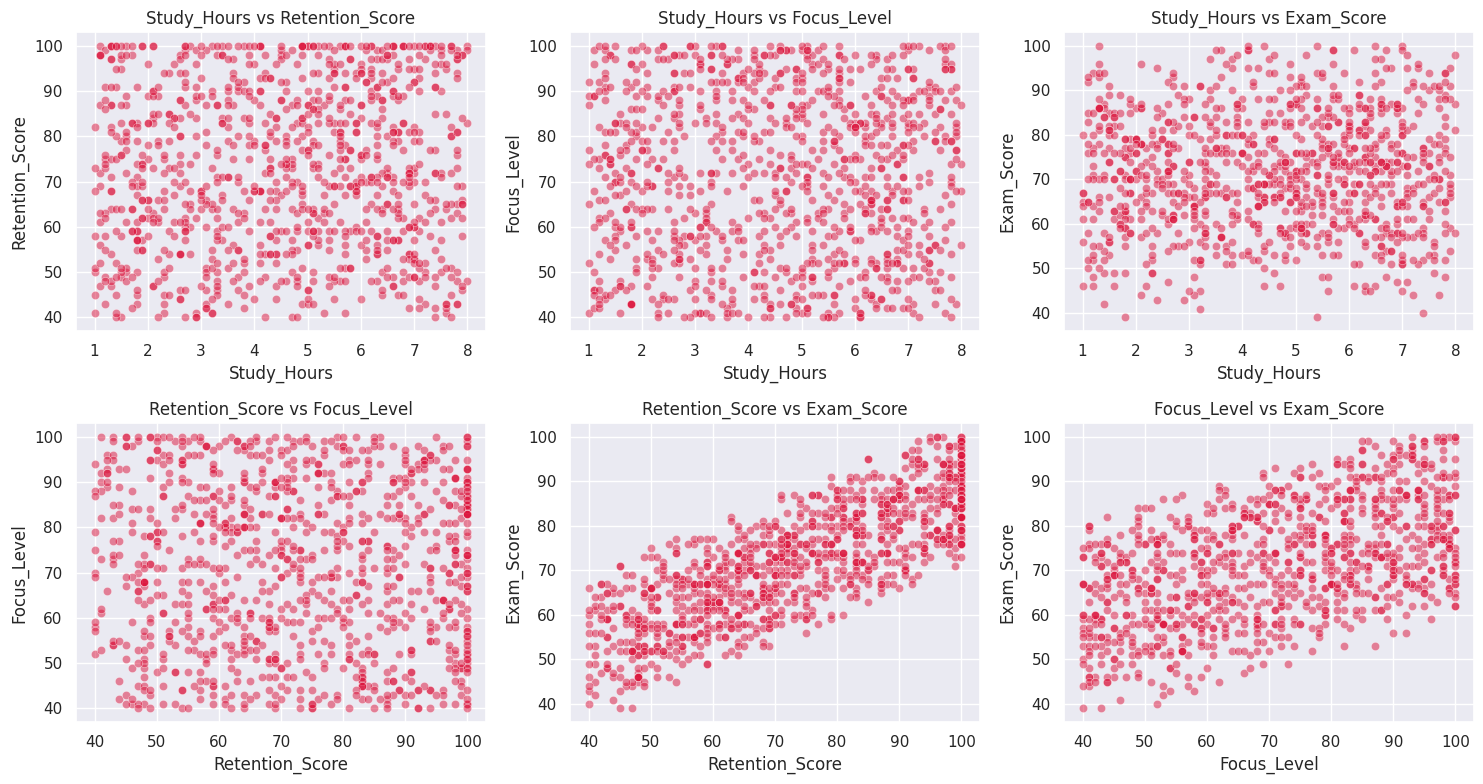

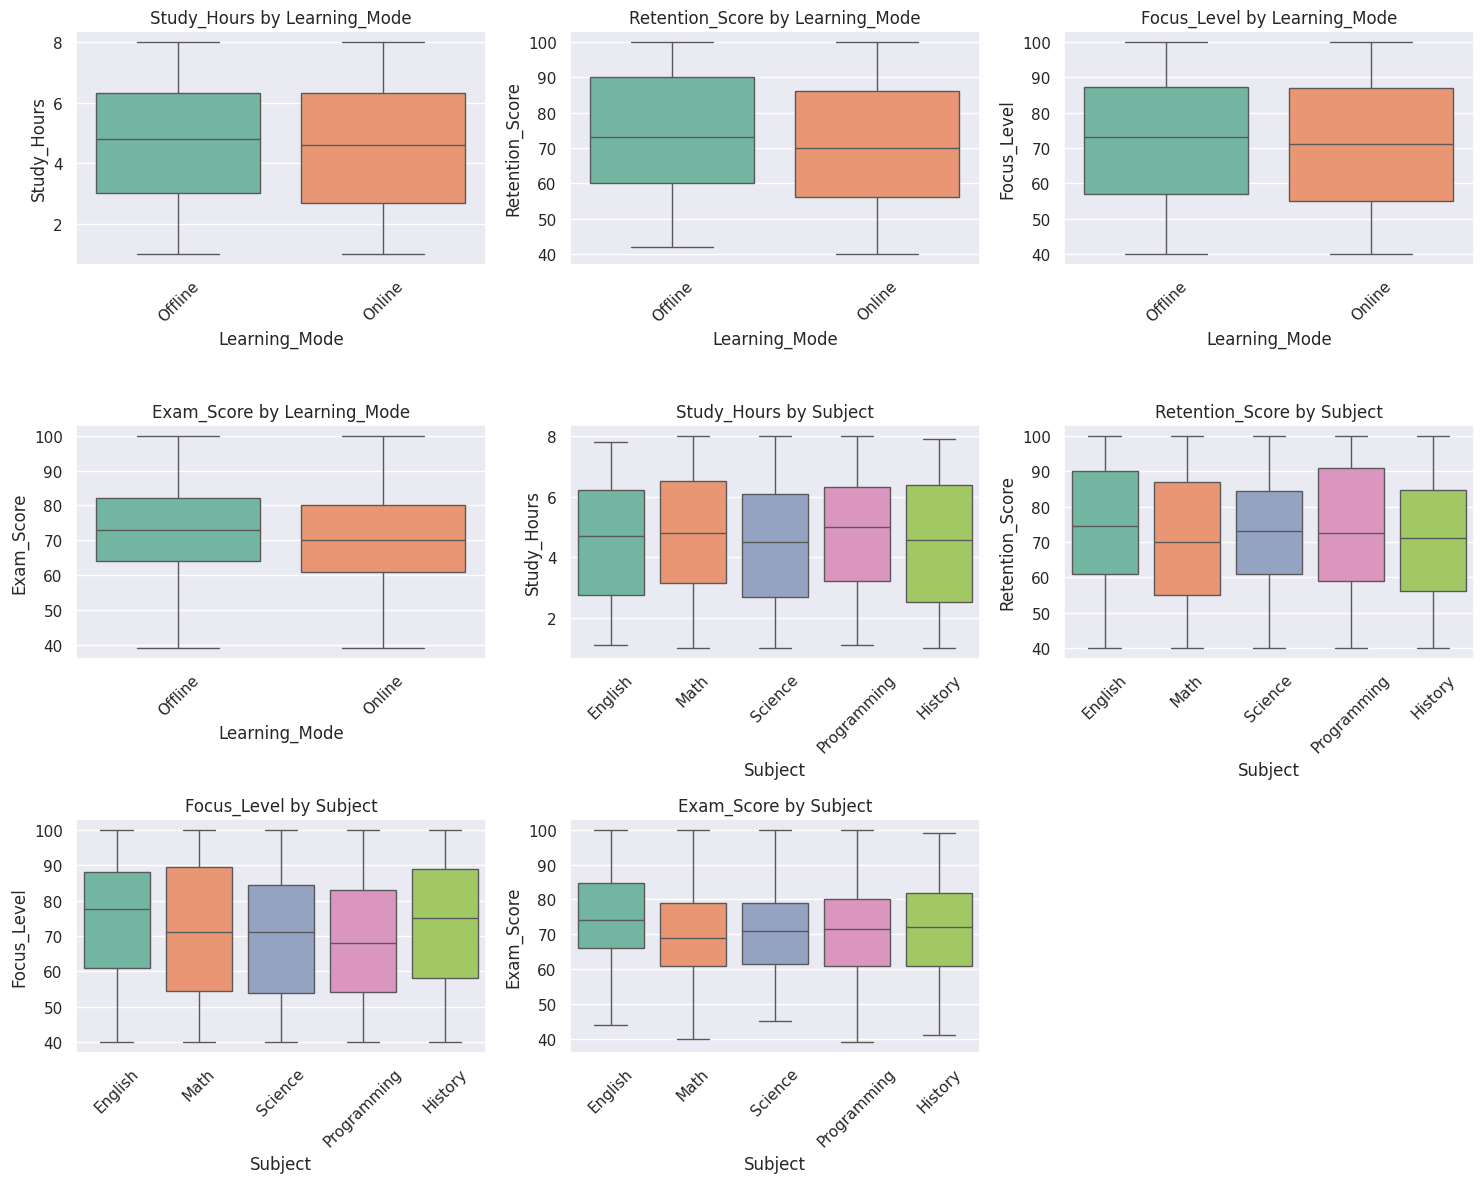

In [20]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")

# Multivariate Analysis


Analyzing relationships with Hue: Learning_Mode...


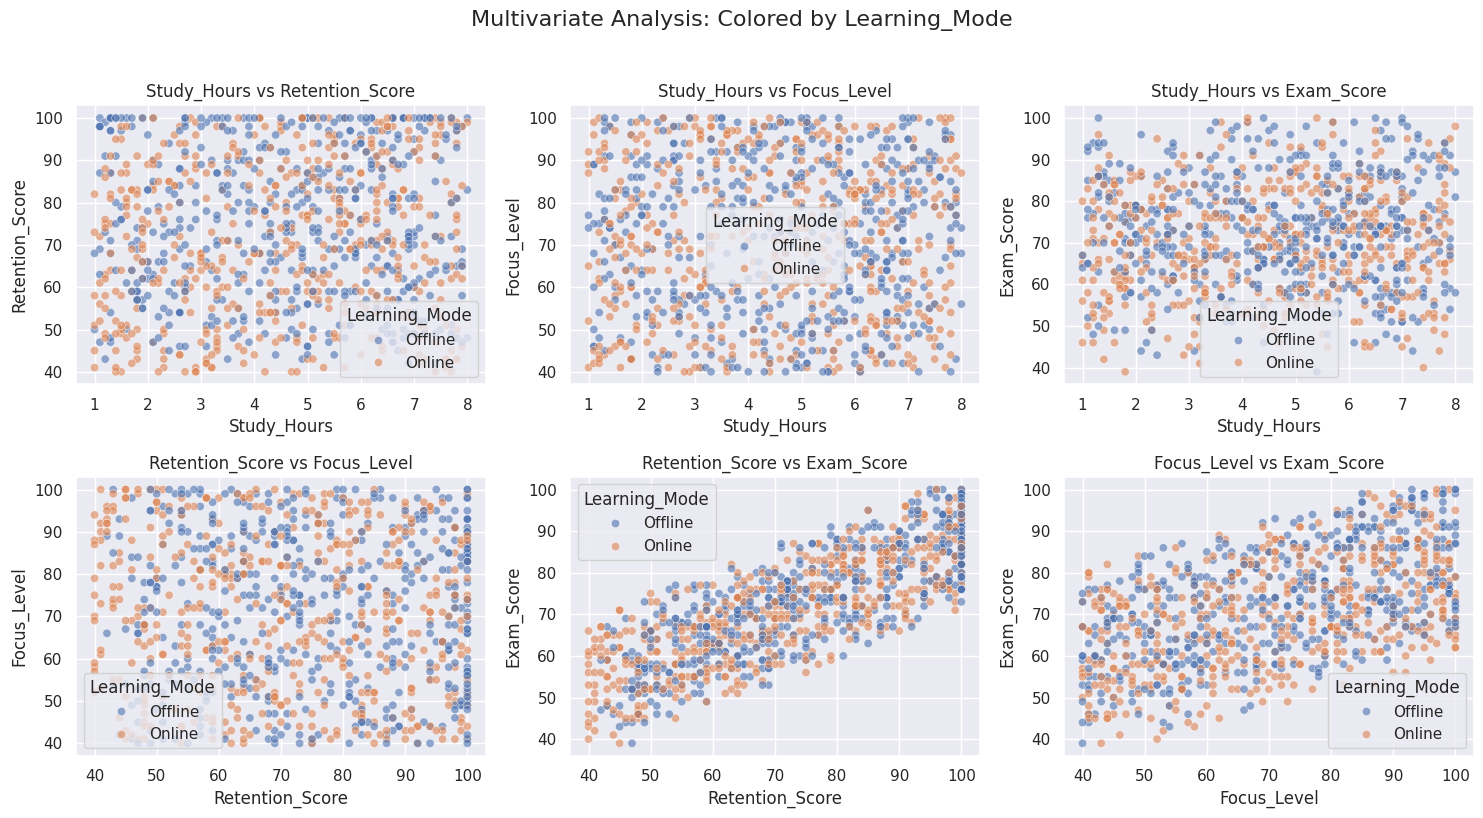


Analyzing relationships with Hue: Subject...


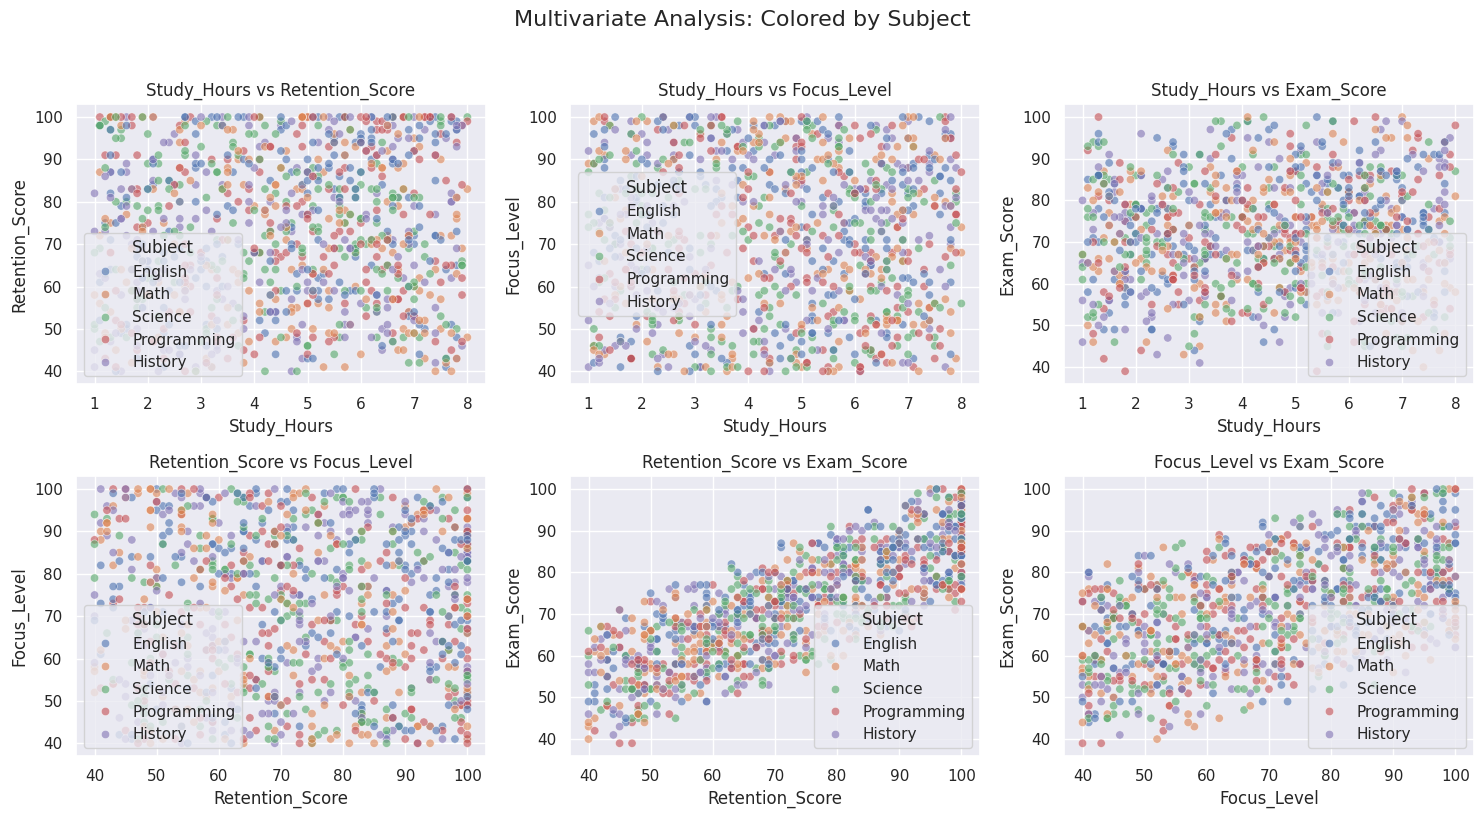

In [21]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

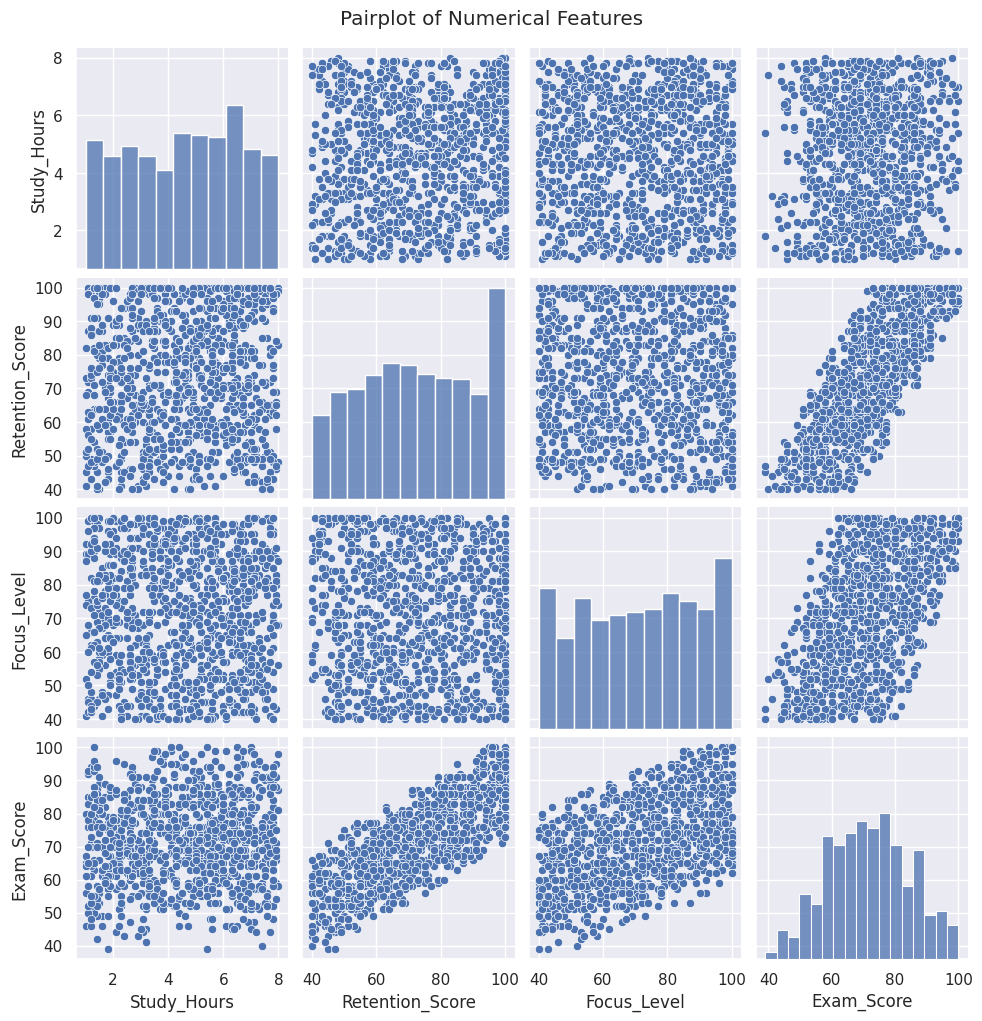

In [22]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

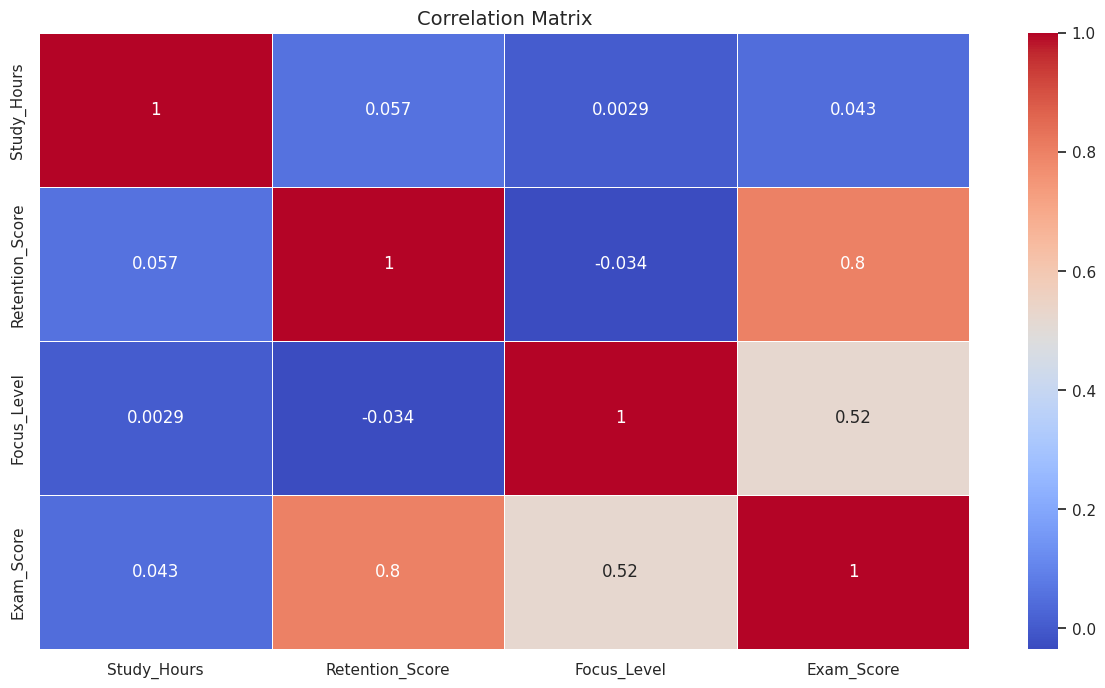

In [23]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- Categorical Value Counts (% of Total) ---

Percentage counts for Learning_Mode:
Learning_Mode
Offline    50.00%
Online     50.00%
Name: proportion, dtype: object

Percentage counts for Subject:
Subject
Science        21.50%
English        21.00%
History        19.80%
Math           19.50%
Programming    18.20%
Name: proportion, dtype: object


ADVANCED CORRELATION ANALYSIS


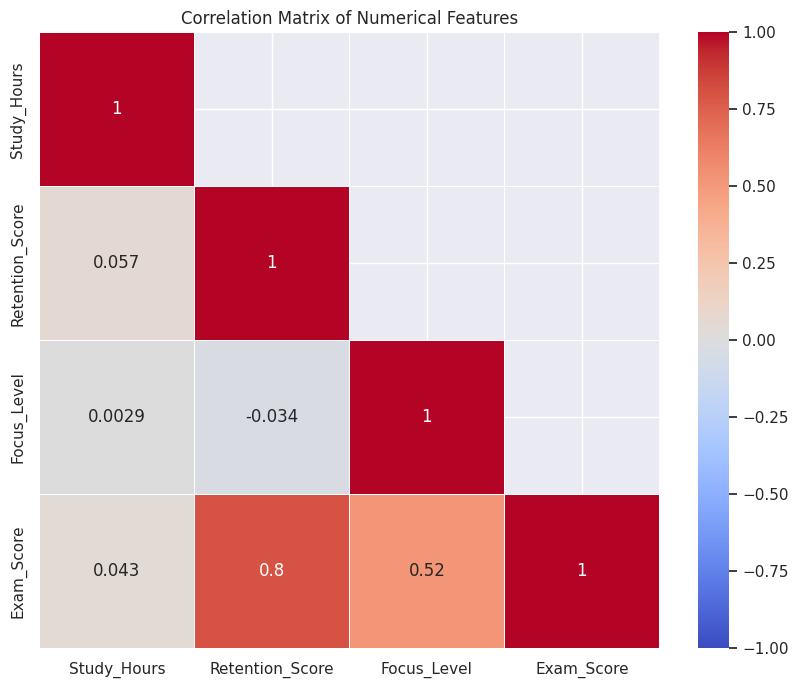


Top Correlations (by absolute value):


,Feature 1,Feature 2,Correlation,Abs Correlation
13,Exam_Score,Retention_Score,0.798222,0.798222
11,Focus_Level,Exam_Score,0.522775,0.522775
1,Study_Hours,Retention_Score,0.056588,0.056588
3,Study_Hours,Exam_Score,0.042705,0.042705
6,Retention_Score,Focus_Level,-0.034454,0.034454




ADVANCED HYPOTHESIS TESTING

--- T-test: Online vs. Offline ---
Feature               T-statistic      P-value    Cohen d           Conclusion
--------------------------------------------------------------------------------
Study_Hours               -1.0388   2.9915e-01    -0.0657 No Significant Difference
Retention_Score           -3.6476   2.7837e-04    -0.2307 Significant Difference
Focus_Level               -0.9406   3.4715e-01    -0.0595 No Significant Difference
Exam_Score                -3.5792   3.6125e-04    -0.2264 Significant Difference


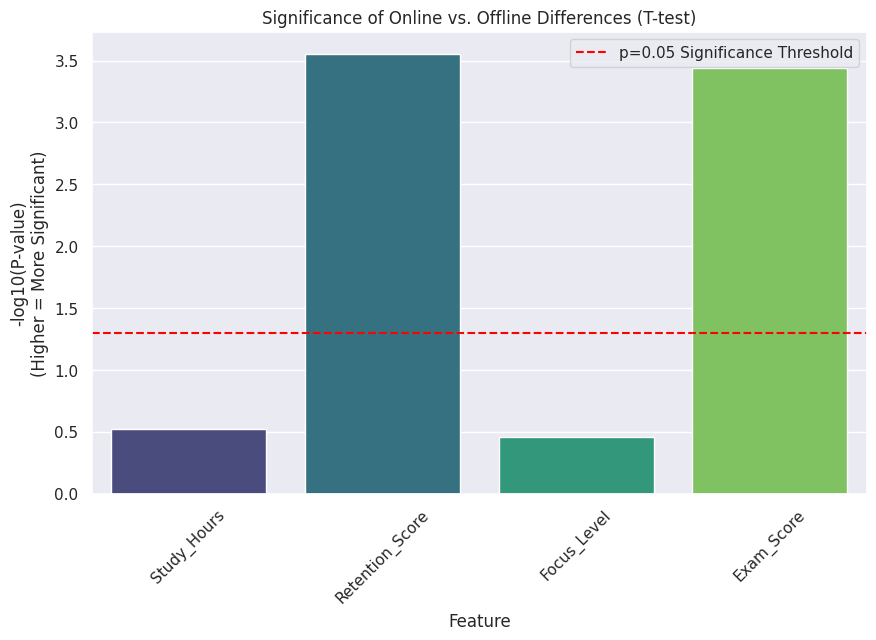


--- ANOVA: Comparing across Subjects ---
Feature               F-statistic      P-value           Conclusion
--------------------------------------------------------------------------------
Study_Hours                1.2823   2.7509e-01 No Significant Difference
Retention_Score            2.2834   5.8618e-02 No Significant Difference
Focus_Level                2.8266   2.3853e-02 Significant Difference
Exam_Score                 3.0320   1.6860e-02 Significant Difference


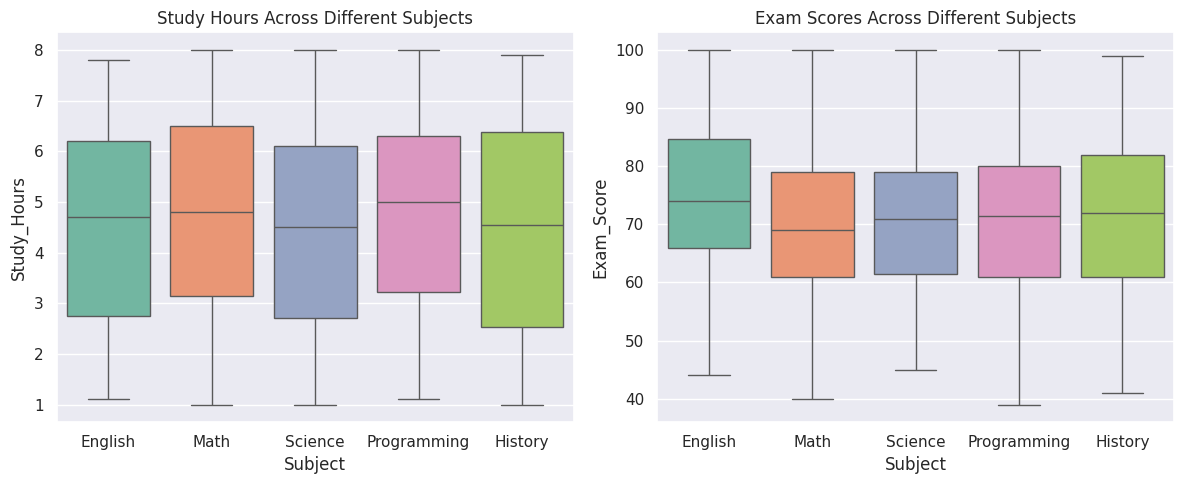



NORMALITY TESTING (Shapiro-Wilk)

Feature                 Statistic      P-value     Normally Distributed?
--------------------------------------------------------------------------------
Study_Hours                0.9543   4.3284e-17            No (Reject H0)
Retention_Score            0.9532   2.6383e-17            No (Reject H0)
Focus_Level                0.9490   4.1144e-18            No (Reject H0)
Exam_Score                 0.9915   1.6710e-05            No (Reject H0)

Note: The Shapiro-Wilk test is highly sensitive to large sample sizes.
Even small deviations from normality can be flagged as significant.
With N=1000, the Central Limit Theorem provides strong justification for using t-tests.
The Q-Q plots below provide a visual check for normality.


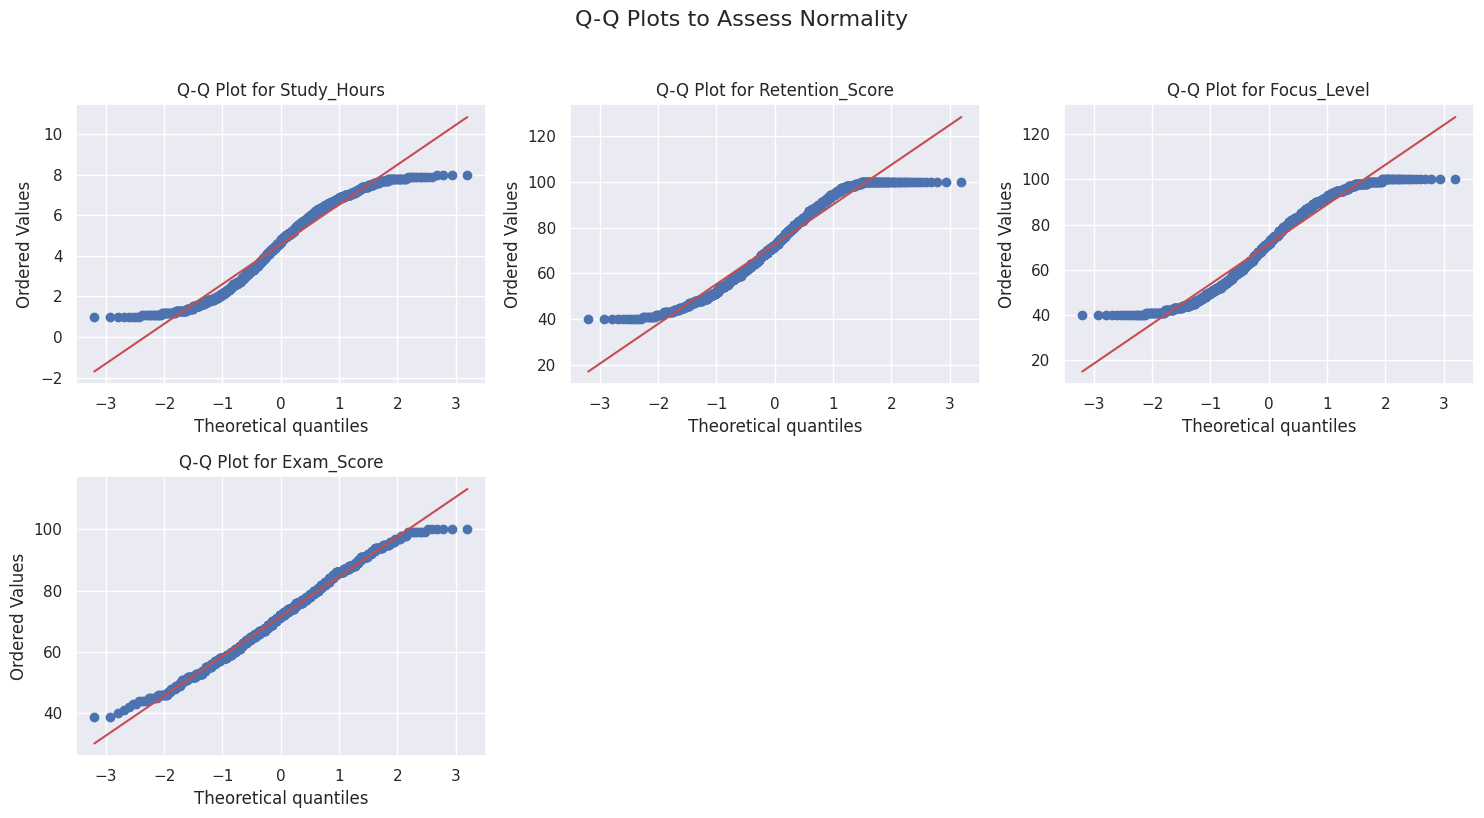

In [24]:
from scipy import stats
import math
import itertools
warnings.filterwarnings('ignore')

# Ensure data is loaded
try:
    df.head()
except NameError:
    print("Dataframe not found. Please run the previous cells to load the data.")
    # You could add a fallback here to load the data if needed
    # df = pd.read_csv('online_vs_offline_learning_dataset.csv')


# --- Display Value Counts as Percentages ---
print("--- Categorical Value Counts (% of Total) ---")
for col in categorical_cols:
    print(f"\nPercentage counts for {col}:")
    print(df[col].value_counts(normalize=True).map('{:.2%}'.format))

print("\n\n" + "="*80)

# =============================================================================
# 1. Advanced Correlation Analysis
# =============================================================================
print("ADVANCED CORRELATION ANALYSIS")
print("="*80)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numerical_cols].corr()

# Visualize with a heatmap for a more professional look
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1) # Mask for upper triangle
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=mask, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Identify the strongest correlations
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]
# Remove duplicate pairs
corr_pairs = corr_pairs.iloc[::2]
# Sort by absolute correlation
corr_pairs['Abs Correlation'] = np.abs(corr_pairs['Correlation'])
strongest_corr = corr_pairs.sort_values('Abs Correlation', ascending=False)

print("\nTop Correlations (by absolute value):")
display(strongest_corr.head(5))

# =============================================================================
# 2. Advanced Hypothesis Testing (Comparing Groups)
# =============================================================================
print("\n\n" + "="*80)
print("ADVANCED HYPOTHESIS TESTING")
print("="*80)

online_df = df[df['Learning_Mode'] == 'Online']
offline_df = df[df['Learning_Mode'] == 'Offline']

# --- 2a. T-test: Online vs. Offline for each numerical feature ---
print("\n--- T-test: Online vs. Offline ---")
print(f"{'Feature':<20} {'T-statistic':>12} {'P-value':>12} {'Cohen d':>10} {'Conclusion':>20}")
print("-" * 80)

ttest_results = []
for feature in numerical_cols:
    online_group = online_df[feature]
    offline_group = offline_df[feature]

    # Independent Samples T-test
    t_stat, p_val = stats.ttest_ind(online_group, offline_group)

    # Effect Size (Cohen's d)
    n1, n2 = len(online_group), len(offline_group)
    s1, s2 = online_group.std(), offline_group.std()
    # Pooled standard deviation
    s = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    cohens_d = (online_group.mean() - offline_group.mean()) / s

    # Conclusion based on p-value
    alpha = 0.05
    conclusion = "Significant Difference" if p_val < alpha else "No Significant Difference"

    ttest_results.append([feature, t_stat, p_val, cohens_d, conclusion])

    print(f"{feature:<20} {t_stat:12.4f} {p_val:12.4e} {cohens_d:10.4f} {conclusion:>20}")

# Create a nice visualization of the t-test results
plt.figure(figsize=(10, 6))
results_df = pd.DataFrame(ttest_results, columns=['Feature', 'T-statistic', 'P-value', "Cohen's d", 'Conclusion'])
results_df['-log10(P-value)'] = -np.log10(results_df['P-value'])
sns.barplot(data=results_df, x='Feature', y='-log10(P-value)', palette='viridis')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05 Significance Threshold')
plt.title('Significance of Online vs. Offline Differences (T-test)')
plt.ylabel('-log10(P-value)\n(Higher = More Significant)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# --- 2b. ANOVA: Comparing across different Subjects ---
print("\n--- ANOVA: Comparing across Subjects ---")
print(f"{'Feature':<20} {'F-statistic':>12} {'P-value':>12} {'Conclusion':>20}")
print("-" * 80)

subjects = df['Subject'].unique()
for feature in numerical_cols:
    groups = [df[df['Subject'] == subject][feature] for subject in subjects]
    f_stat, p_val = stats.f_oneway(*groups)

    alpha = 0.05
    conclusion = "Significant Difference" if p_val < alpha else "No Significant Difference"

    print(f"{feature:<20} {f_stat:12.4f} {p_val:12.4e} {conclusion:>20}")

# Example boxplot to visually support ANOVA (showing Study_Hours by Subject)
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='Subject', y='Study_Hours', palette='Set2')
plt.title('Study Hours Across Different Subjects')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Subject', y='Exam_Score', palette='Set2')
plt.title('Exam Scores Across Different Subjects')
plt.tight_layout()
plt.show()

# =============================================================================
# 3. Normality Testing for Key Numerical Features
# =============================================================================
print("\n\n" + "="*80)
print("NORMALITY TESTING (Shapiro-Wilk)")
print("="*80)

# We test the overall distribution for each numerical feature.
# The null hypothesis (H0) is that the data is drawn from a normal distribution.
print(f"\n{'Feature':<20} {'Statistic':>12} {'P-value':>12} {'Normally Distributed?':>25}")
print("-" * 80)

for feature in numerical_cols:
    stat, p_val = stats.shapiro(df[feature])

    alpha = 0.05
    is_normal = "Yes (Fail to Reject H0)" if p_val > alpha else "No (Reject H0)"

    print(f"{feature:<20} {stat:12.4f} {p_val:12.4e} {is_normal:>25}")

print("\nNote: The Shapiro-Wilk test is highly sensitive to large sample sizes.")
print("Even small deviations from normality can be flagged as significant.")
print("With N=1000, the Central Limit Theorem provides strong justification for using t-tests.")
print("The Q-Q plots below provide a visual check for normality.")

# Visual check using Q-Q plots
num_plots = len(numerical_cols)
num_cols_plot = 3
num_rows_plot = math.ceil(num_plots / num_cols_plot)

fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    stats.probplot(df[feature], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot for {feature}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Q-Q Plots to Assess Normality', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Feature Engineering

FEATURE ENGINEERING & VISUALIZATION


1. INTERACTION FEATURES
--------------------------------------------------------------------------------
Creating new features by multiplying pairs of numerical features
to capture their combined effects.

New interaction features created:
  • Study_Retention_Interaction
  • Study_Focus_Interaction
  • Retention_Focus_Interaction
  • Efficiency_Ratio
  • Focus_Efficiency


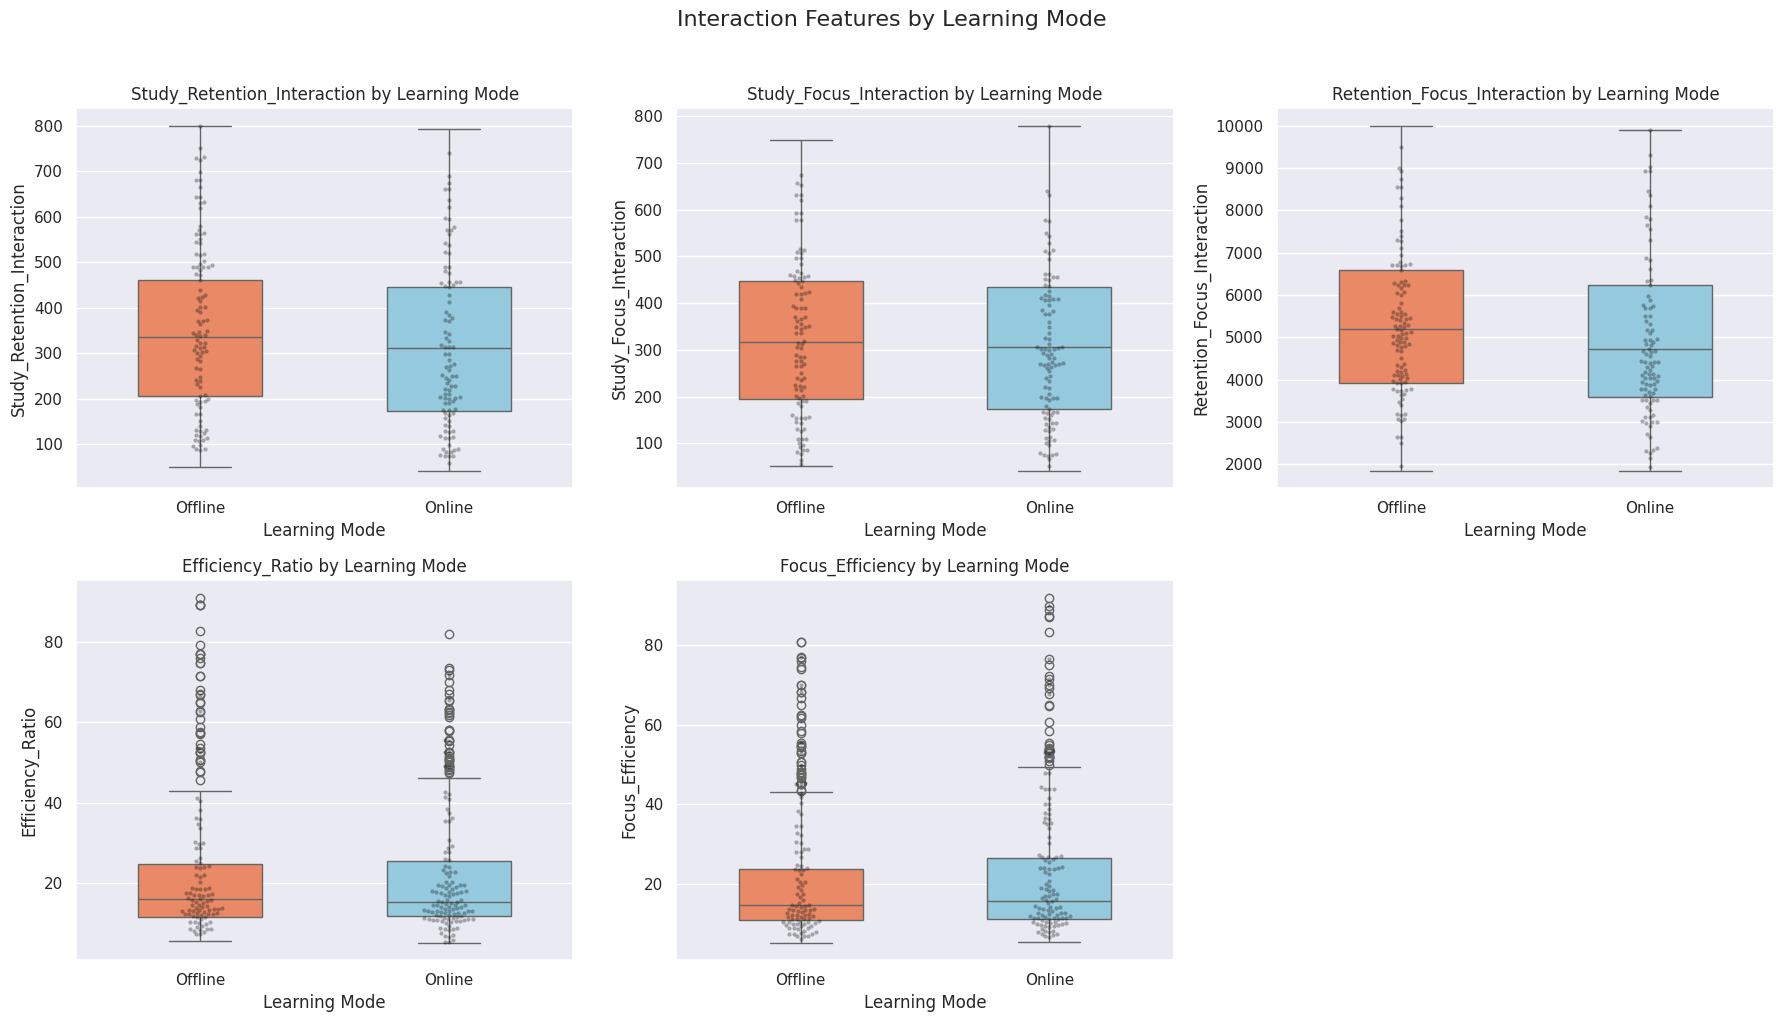


T-test results for Interaction Features (Online vs Offline):
Feature                              T-statistic      P-value    Cohen d
---------------------------------------------------------------------------
Study_Retention_Interaction              -2.1782   2.9628e-02    -0.1378 *
Study_Focus_Interaction                  -1.2853   1.9898e-01    -0.0813 
Retention_Focus_Interaction              -3.4757   5.3152e-04    -0.2198 ***
Efficiency_Ratio                         -0.3263   7.4430e-01    -0.0206 
Focus_Efficiency                          0.8971   3.6987e-01     0.0567 


2. POLYNOMIAL FEATURES
--------------------------------------------------------------------------------
Creating squared and cubed features to capture non-linear relationships.



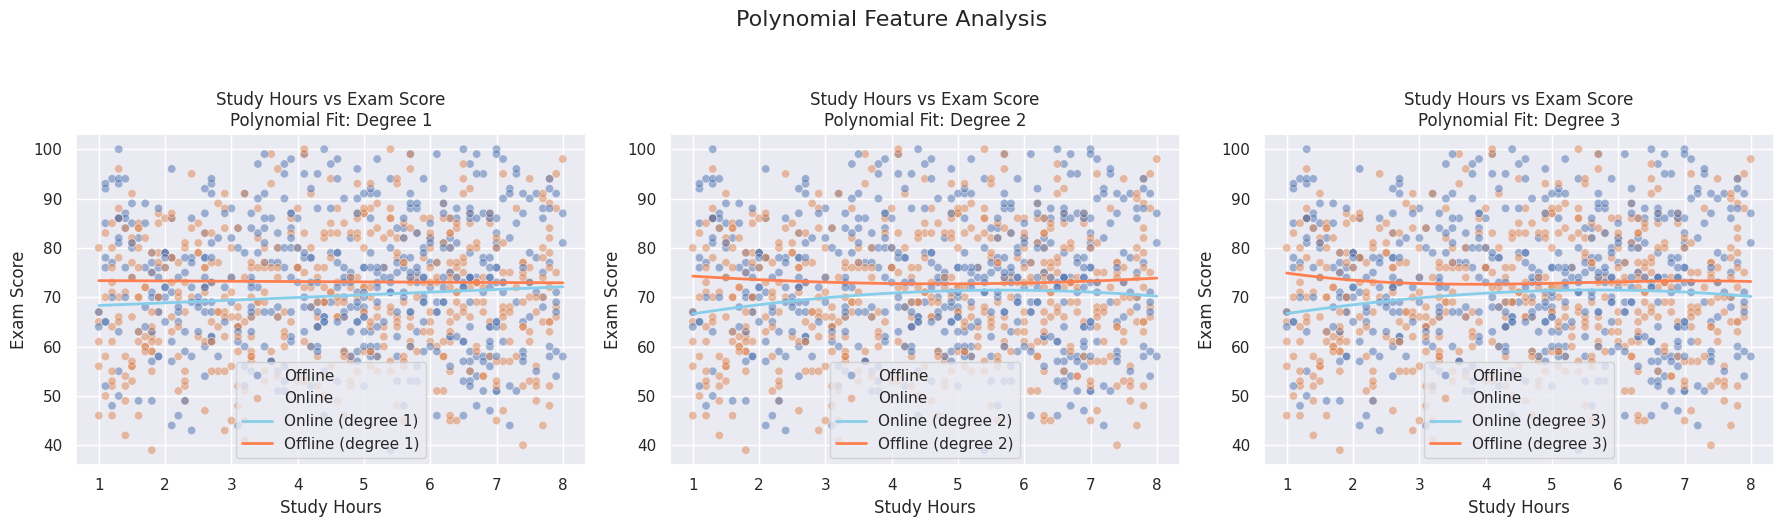


R² Scores for Different Polynomial Degrees:
Degree     R² (Online)     R² (Offline)   
---------------------------------------------
1          0.0075          0.0001         
2          0.0116          0.0010         
3          0.0116          0.0013         


3. BINNING & DISCRETIZATION
--------------------------------------------------------------------------------


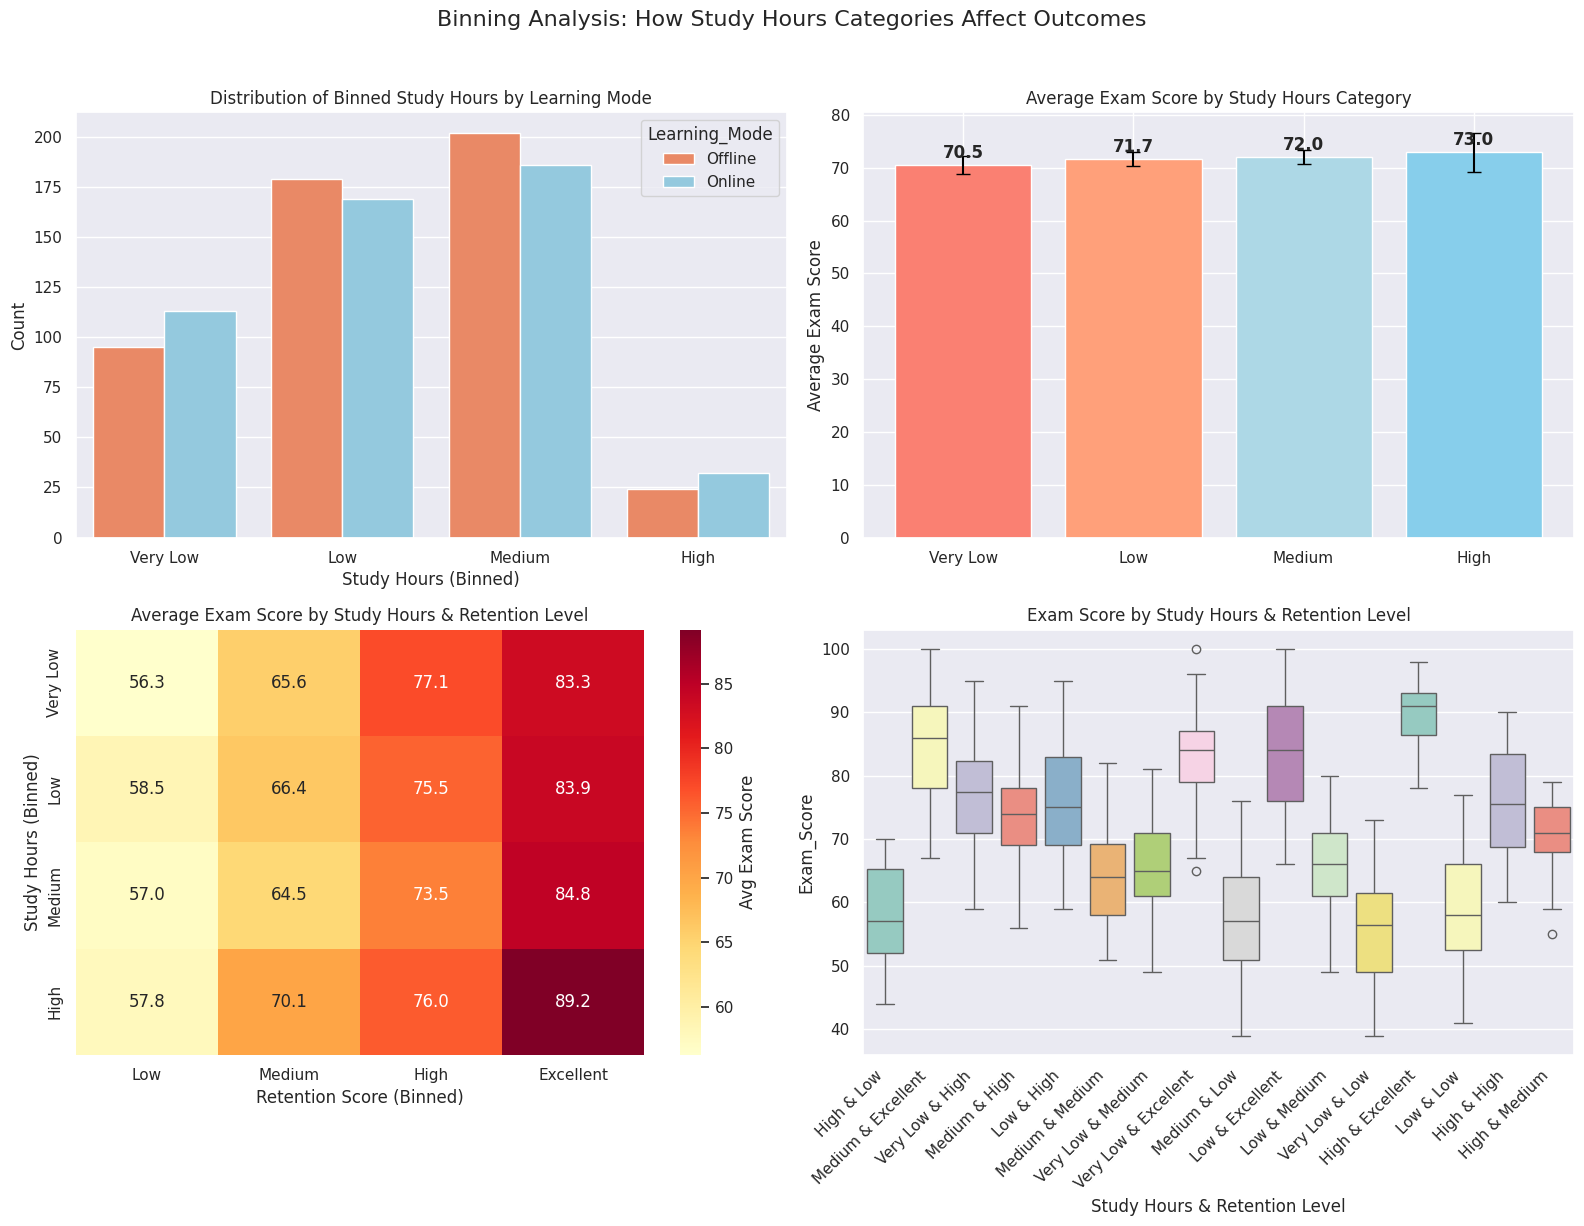



4. LOG TRANSFORMATION & SKEWNESS CORRECTION
--------------------------------------------------------------------------------

Skewness of original features:
Feature                     Skewness                 Interpretation
----------------------------------------------------------------------
Study_Hours                  -0.1113        Approximately symmetric
Retention_Score              -0.0383        Approximately symmetric
Focus_Level                  -0.0871        Approximately symmetric
Exam_Score                    0.0035        Approximately symmetric


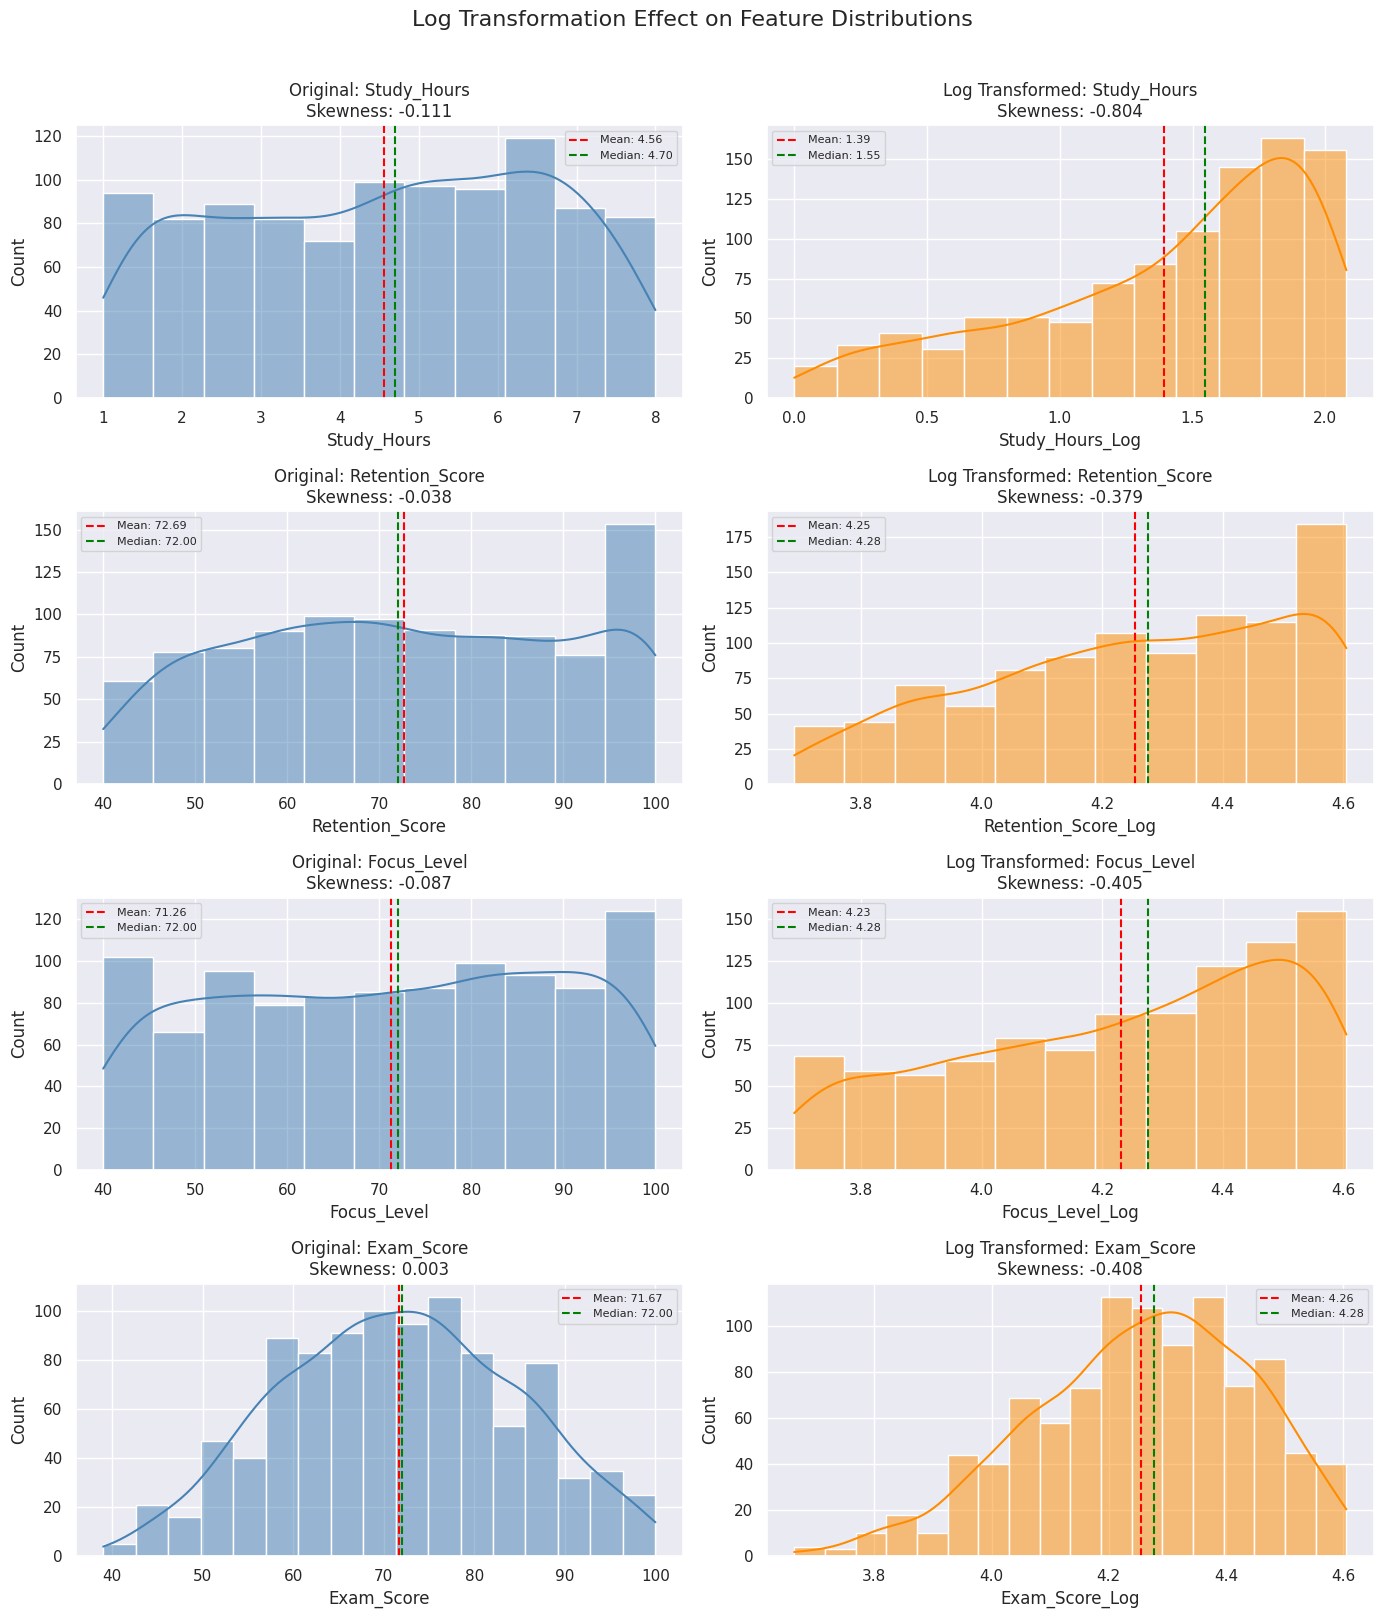



5. FEATURE SCALING & NORMALIZATION
--------------------------------------------------------------------------------


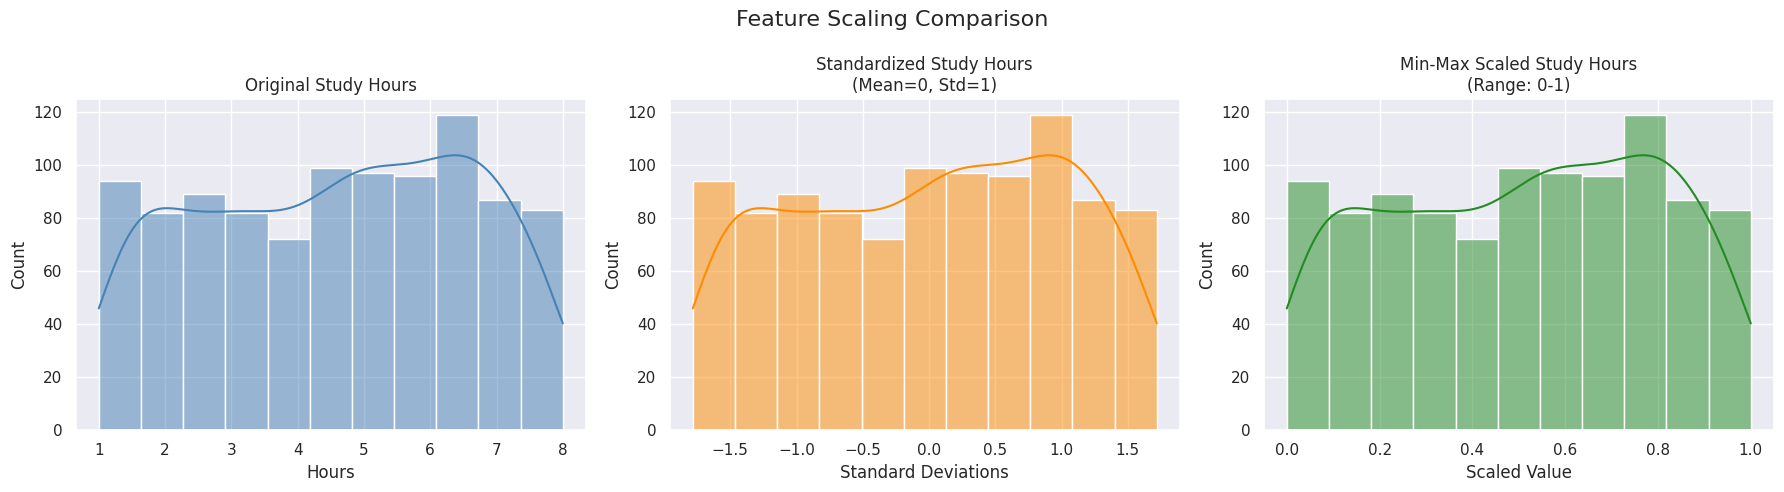



6. CORRELATION ANALYSIS: ALL FEATURES (Original & Engineered)
--------------------------------------------------------------------------------

Feature Correlation with Exam_Score (Target):
Feature                                   Correlation
-------------------------------------------------------
Retention_Focus_Interaction              +0.9341 ██████████████████
Retention_Score                          +0.7982 ███████████████
Retention_Score_Squared                  +0.7952 ███████████████
Focus_Level                              +0.5228 ██████████
Focus_Level_Squared                      +0.5172 ██████████
Study_Retention_Interaction              +0.4132 ████████
Study_Focus_Interaction                  +0.2933 █████
Efficiency_Ratio                         +0.2406 ████
Focus_Efficiency                         +0.1417 ██
Study_Hours                              +0.0427 
Study_Hours_Squared                      +0.0371 
Study_Hours_Cubed                        +0.0316 


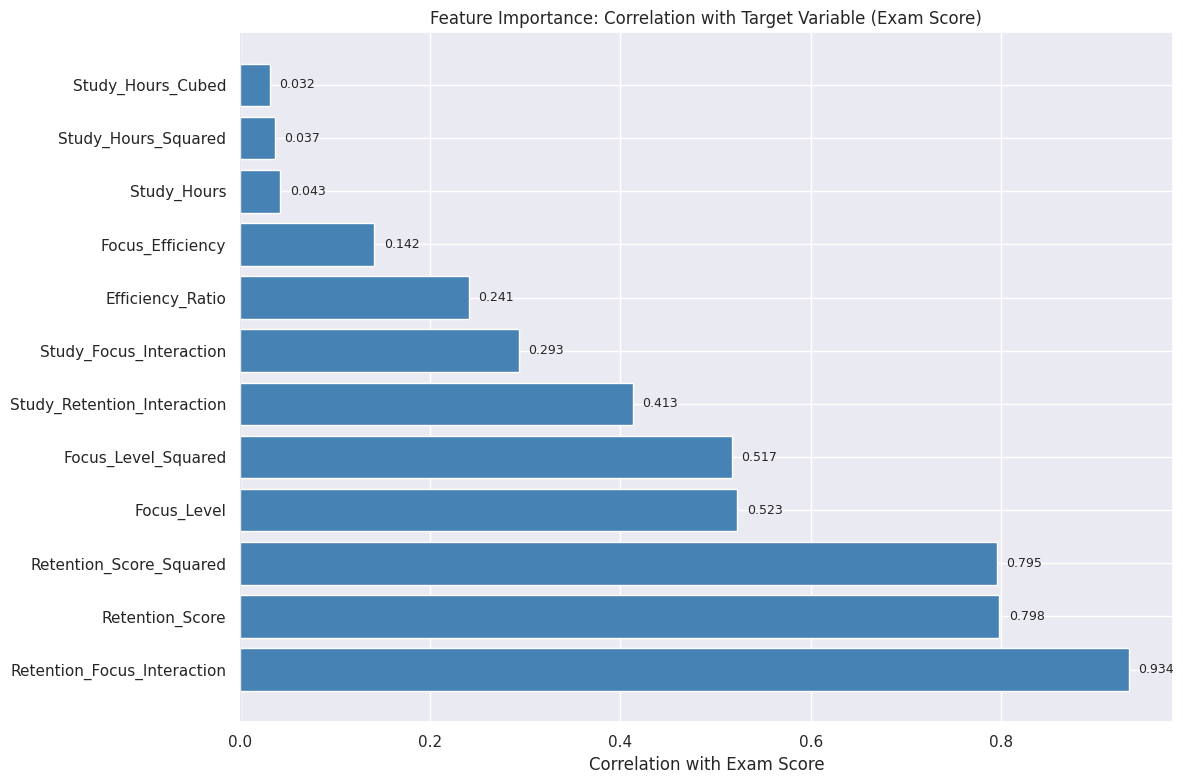



7. SUMMARY OF ALL ENGINEERED FEATURES
--------------------------------------------------------------------------------

Complete list of engineered features created:
  • Study_Retention_Interaction  (dtype: float64) 
  • Study_Focus_Interaction  (dtype: float64) 
  • Retention_Focus_Interaction  (dtype: int64) 
  • Efficiency_Ratio  (dtype: float64) 
  • Focus_Efficiency  (dtype: float64) 
  • Study_Hours_Squared  (dtype: float64) 
  • Study_Hours_Cubed  (dtype: float64) 
  • Retention_Score_Squared  (dtype: int64) 
  • Focus_Level_Squared  (dtype: int64) 
  • Study_Hours_Binned  (dtype: category) 
  • Retention_Score_Binned  (dtype: category) 
  • Study_Retention_Bin  (dtype: object) 

Total original features: 6
Total engineered features: 9
Total binned/categorical features: 3

Final DataFrame shape: (1000, 30)
Final columns: ['Learning_Mode', 'Subject', 'Study_Hours', 'Retention_Score', 'Focus_Level', 'Exam_Score', 'Study_Retention_Interaction', 'Study_Focus_Interaction', 'Retentio

In [25]:
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
warnings.filterwarnings('ignore')

# Ensure data is loaded
try:
    df.head()
except NameError:
    print("DataFrame 'df' not found. Please run the previous cells to load the data.")

# Create a copy for feature engineering
df_fe = df.copy()

print("=" * 80)
print("FEATURE ENGINEERING & VISUALIZATION")
print("=" * 80)

# =============================================================================
# 1. INTERACTION FEATURES
# =============================================================================
print("\n\n1. INTERACTION FEATURES")
print("-" * 80)
print("Creating new features by multiplying pairs of numerical features")
print("to capture their combined effects.\n")

numerical_cols = df_fe.select_dtypes(include=np.number).columns.tolist()

# Create interaction features
df_fe['Study_Retention_Interaction'] = df_fe['Study_Hours'] * df_fe['Retention_Score']
df_fe['Study_Focus_Interaction'] = df_fe['Study_Hours'] * df_fe['Focus_Level']
df_fe['Retention_Focus_Interaction'] = df_fe['Retention_Score'] * df_fe['Focus_Level']
df_fe['Efficiency_Ratio'] = df_fe['Retention_Score'] / df_fe['Study_Hours'].replace(0, np.nan)
df_fe['Focus_Efficiency'] = df_fe['Focus_Level'] / df_fe['Study_Hours'].replace(0, np.nan)

print("New interaction features created:")
interaction_features = [
    'Study_Retention_Interaction',
    'Study_Focus_Interaction',
    'Retention_Focus_Interaction',
    'Efficiency_Ratio',
    'Focus_Efficiency'
]
for feat in interaction_features:
    print(f"  • {feat}")

# Visualize interaction features by Learning Mode
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(interaction_features):
    # Boxplot by Learning Mode
    sns.boxplot(data=df_fe, x='Learning_Mode', y=feat, ax=axes[i],
                palette={'Online': 'skyblue', 'Offline': 'coral'}, width=0.5)
    axes[i].set_title(f'{feat} by Learning Mode')
    axes[i].set_xlabel('Learning Mode')

    # Add swarm plot for individual data points (subsample for performance)
    sample = df_fe.sample(min(200, len(df_fe)))
    sns.swarmplot(data=sample, x='Learning_Mode', y=feat, ax=axes[i],
                  color='black', alpha=0.3, size=3)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Interaction Features by Learning Mode', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Statistical test for interaction features
print("\nT-test results for Interaction Features (Online vs Offline):")
print(f"{'Feature':<35} {'T-statistic':>12} {'P-value':>12} {'Cohen d':>10}")
print("-" * 75)

for feat in interaction_features:
    online_group = df_fe[df_fe['Learning_Mode'] == 'Online'][feat].dropna()
    offline_group = df_fe[df_fe['Learning_Mode'] == 'Offline'][feat].dropna()

    t_stat, p_val = stats.ttest_ind(online_group, offline_group)

    # Cohen's d
    n1, n2 = len(online_group), len(offline_group)
    s1, s2 = online_group.std(), offline_group.std()
    s = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    cohens_d = (online_group.mean() - offline_group.mean()) / s if s != 0 else 0

    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""

    print(f"{feat:<35} {t_stat:12.4f} {p_val:12.4e} {cohens_d:10.4f} {significance}")

# =============================================================================
# 2. POLYNOMIAL FEATURES
# =============================================================================
print("\n\n" + "=" * 80)
print("2. POLYNOMIAL FEATURES")
print("-" * 80)
print("Creating squared and cubed features to capture non-linear relationships.\n")

# Create polynomial features for Study_Hours (commonly has non-linear relationships)
df_fe['Study_Hours_Squared'] = df_fe['Study_Hours'] ** 2
df_fe['Study_Hours_Cubed'] = df_fe['Study_Hours'] ** 3
df_fe['Retention_Score_Squared'] = df_fe['Retention_Score'] ** 2
df_fe['Focus_Level_Squared'] = df_fe['Focus_Level'] ** 2

# Visualize polynomial relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Study Hours vs Exam Score with polynomial fits
for i, degree in enumerate([1, 2, 3]):
    ax = axes[i]

    # Scatter plot
    sns.scatterplot(data=df_fe, x='Study_Hours', y='Exam_Score',
                    hue='Learning_Mode', alpha=0.5, ax=ax)

    # Polynomial fit for all data
    x_range = np.linspace(df_fe['Study_Hours'].min(), df_fe['Study_Hours'].max(), 100)

    for mode, color in [('Online', 'skyblue'), ('Offline', 'coral')]:
        subset = df_fe[df_fe['Learning_Mode'] == mode]
        coeffs = np.polyfit(subset['Study_Hours'], subset['Exam_Score'], degree)
        poly_func = np.poly1d(coeffs)
        ax.plot(x_range, poly_func(x_range), color=color, linewidth=2,
                label=f'{mode} (degree {degree})')

    ax.set_title(f'Study Hours vs Exam Score\nPolynomial Fit: Degree {degree}')
    ax.set_xlabel('Study Hours')
    ax.set_ylabel('Exam Score')
    ax.legend()

plt.suptitle('Polynomial Feature Analysis', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Calculate and display R² for different polynomial degrees
print("\nR² Scores for Different Polynomial Degrees:")
print(f"{'Degree':<10} {'R² (Online)':<15} {'R² (Offline)':<15}")
print("-" * 45)

for degree in range(1, 4):
    scores = {}
    for mode in ['Online', 'Offline']:
        subset = df_fe[df_fe['Learning_Mode'] == mode]
        coeffs = np.polyfit(subset['Study_Hours'], subset['Exam_Score'], degree)
        poly_func = np.poly1d(coeffs)
        y_pred = poly_func(subset['Study_Hours'])
        ss_res = np.sum((subset['Exam_Score'] - y_pred) ** 2)
        ss_tot = np.sum((subset['Exam_Score'] - subset['Exam_Score'].mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        scores[mode] = r2

    print(f"{degree:<10} {scores['Online']:<15.4f} {scores['Offline']:<15.4f}")

# =============================================================================
# 3. BINNING/DISCRETIZATION
# =============================================================================
print("\n\n" + "=" * 80)
print("3. BINNING & DISCRETIZATION")
print("-" * 80)

# Bin Study_Hours into categories
study_bins = [0, 2.5, 5, 7.5, 10]
study_labels = ['Very Low', 'Low', 'Medium', 'High']
df_fe['Study_Hours_Binned'] = pd.cut(df_fe['Study_Hours'], bins=study_bins,
                                       labels=study_labels, include_lowest=True)

# Bin Retention_Score into categories
retention_bins = [0, 55, 70, 85, 100]
retention_labels = ['Low', 'Medium', 'High', 'Excellent']
df_fe['Retention_Score_Binned'] = pd.cut(df_fe['Retention_Score'], bins=retention_bins,
                                           labels=retention_labels, include_lowest=True)

# Visualize binned features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Count plot of binned Study Hours
ax = axes[0, 0]
sns.countplot(data=df_fe, x='Study_Hours_Binned', hue='Learning_Mode',
              palette={'Online': 'skyblue', 'Offline': 'coral'}, ax=ax)
ax.set_title('Distribution of Binned Study Hours by Learning Mode')
ax.set_xlabel('Study Hours (Binned)')
ax.set_ylabel('Count')

# 2. Average Exam Score by Study Hours Bin
ax = axes[0, 1]
study_bin_stats = df_fe.groupby('Study_Hours_Binned')['Exam_Score'].agg(['mean', 'std']).reset_index()
study_bin_stats['ci'] = 1.96 * study_bin_stats['std'] / np.sqrt(df_fe.groupby('Study_Hours_Binned').size().values)

bars = ax.bar(range(len(study_bin_stats)), study_bin_stats['mean'],
              color=['salmon', 'lightsalmon', 'lightblue', 'skyblue'])
ax.errorbar(range(len(study_bin_stats)), study_bin_stats['mean'],
           yerr=study_bin_stats['ci'], fmt='none', color='black', capsize=5)
ax.set_xticks(range(len(study_bin_stats)))
ax.set_xticklabels(study_bin_stats['Study_Hours_Binned'])
ax.set_title('Average Exam Score by Study Hours Category')
ax.set_ylabel('Average Exam Score')

# Add value labels on bars
for bar, val in zip(bars, study_bin_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# 3. Heatmap: Study Hours Bin vs Retention Score Bin
ax = axes[1, 0]
pivot_table = pd.crosstab(df_fe['Study_Hours_Binned'], df_fe['Retention_Score_Binned'],
                           values=df_fe['Exam_Score'], aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Avg Exam Score'})
ax.set_title('Average Exam Score by Study Hours & Retention Level')
ax.set_xlabel('Retention Score (Binned)')
ax.set_ylabel('Study Hours (Binned)')

# 4. Interaction: Study Hours Bin × Retention Score Bin
ax = axes[1, 1]
# Create compound category
df_fe['Study_Retention_Bin'] = df_fe['Study_Hours_Binned'].astype(str) + ' & ' + df_fe['Retention_Score_Binned'].astype(str)
sns.boxplot(data=df_fe, x='Study_Retention_Bin', y='Exam_Score', palette='Set3', ax=ax)
ax.set_title('Exam Score by Study Hours & Retention Level')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Study Hours & Retention Level')

plt.suptitle('Binning Analysis: How Study Hours Categories Affect Outcomes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. LOG TRANSFORMATION & SKEWNESS CORRECTION
# =============================================================================
print("\n\n" + "=" * 80)
print("4. LOG TRANSFORMATION & SKEWNESS CORRECTION")
print("-" * 80)

# Check skewness of numerical features
print("\nSkewness of original features:")
print(f"{'Feature':<25} {'Skewness':>10} {'Interpretation':>30}")
print("-" * 70)

for col in numerical_cols:
    skew_val = df_fe[col].skew()
    if abs(skew_val) < 0.5:
        interpretation = "Approximately symmetric"
    elif abs(skew_val) < 1:
        interpretation = "Moderately skewed"
    else:
        interpretation = "Highly skewed"

    print(f"{col:<25} {skew_val:10.4f} {interpretation:>30}")

# Apply log transformation for features with high skewness
for col in numerical_cols:
    if df_fe[col].min() > 0:  # Log transform requires positive values
        df_fe[f'{col}_Log'] = np.log(df_fe[col])
    else:
        # Min-max shift to make values positive
        min_val = df_fe[col].min()
        if min_val <= 0:
            df_fe[f'{col}_Log'] = np.log(df_fe[col] - min_val + 1)

# Visualize before and after transformations
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Before transformation
    ax1 = axes[i, 0]
    sns.histplot(data=df_fe, x=col, kde=True, ax=ax1, color='steelblue')
    ax1.set_title(f'Original: {col}\nSkewness: {df_fe[col].skew():.3f}')
    ax1.axvline(df_fe[col].mean(), color='red', linestyle='--', label=f'Mean: {df_fe[col].mean():.2f}')
    ax1.axvline(df_fe[col].median(), color='green', linestyle='--', label=f'Median: {df_fe[col].median():.2f}')
    ax1.legend(fontsize=8)

    # After transformation
    ax2 = axes[i, 1]
    log_col = f'{col}_Log'
    sns.histplot(data=df_fe, x=log_col, kde=True, ax=ax2, color='darkorange')
    ax2.set_title(f'Log Transformed: {col}\nSkewness: {df_fe[log_col].skew():.3f}')
    ax2.axvline(df_fe[log_col].mean(), color='red', linestyle='--', label=f'Mean: {df_fe[log_col].mean():.2f}')
    ax2.axvline(df_fe[log_col].median(), color='green', linestyle='--', label=f'Median: {df_fe[log_col].median():.2f}')
    ax2.legend(fontsize=8)

plt.suptitle('Log Transformation Effect on Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# =============================================================================
# 5. FEATURE SCALING & NORMALIZATION VISUALIZATION
# =============================================================================
print("\n\n" + "=" * 80)
print("5. FEATURE SCALING & NORMALIZATION")
print("-" * 80)

# Apply different scaling methods
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

for col in numerical_cols:
    df_fe[f'{col}_Standardized'] = scaler_standard.fit_transform(df_fe[[col]])
    df_fe[f'{col}_MinMax'] = scaler_minmax.fit_transform(df_fe[[col]])

# Visualize scaling effects on Study_Hours
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
ax = axes[0]
sns.histplot(data=df_fe, x='Study_Hours', kde=True, ax=ax, color='steelblue')
ax.set_title('Original Study Hours')
ax.set_xlabel('Hours')

# Standardized
ax = axes[1]
sns.histplot(data=df_fe, x='Study_Hours_Standardized', kde=True, ax=ax, color='darkorange')
ax.set_title('Standardized Study Hours\n(Mean=0, Std=1)')
ax.set_xlabel('Standard Deviations')

# Min-Max Scaled
ax = axes[2]
sns.histplot(data=df_fe, x='Study_Hours_MinMax', kde=True, ax=ax, color='forestgreen')
ax.set_title('Min-Max Scaled Study Hours\n(Range: 0-1)')
ax.set_xlabel('Scaled Value')

plt.suptitle('Feature Scaling Comparison', fontsize=16)
plt.tight_layout()
plt.show()

# =============================================================================
# 6. CORRELATION OF ALL FEATURES (ORIGINAL + ENGINEERED)
# =============================================================================
print("\n\n" + "=" * 80)
print("6. CORRELATION ANALYSIS: ALL FEATURES (Original & Engineered)")
print("-" * 80)

# Select all numerical features (original + engineered)
all_num_cols = df_fe.select_dtypes(include=np.number).columns.tolist()

# Remove scaled/log versions to focus on original and truly new features
exclude_patterns = ['_Standardized', '_MinMax', '_Log']
core_features = [col for col in all_num_cols if not any(p in col for p in exclude_patterns)]

# Calculate correlation with Exam_Score (target variable)
corr_with_target = df_fe[core_features].corr()['Exam_Score'].sort_values(ascending=False)

# Display top features correlated with Exam_Score
print("\nFeature Correlation with Exam_Score (Target):")
print(f"{'Feature':<40} {'Correlation':>12}")
print("-" * 55)

for feat, corr_val in corr_with_target.items():
    if feat != 'Exam_Score':
        bar = '█' * int(abs(corr_val) * 20)
        direction = '+' if corr_val > 0 else '-'
        print(f"{feat:<40} {direction}{abs(corr_val):.4f} {bar}")

# Visualize feature importance (correlation with target)
plt.figure(figsize=(12, 8))
features_to_plot = corr_with_target.drop('Exam_Score')
colors = ['coral' if c < 0 else 'steelblue' for c in features_to_plot.values]

bars = plt.barh(range(len(features_to_plot)), features_to_plot.values, color=colors)
plt.yticks(range(len(features_to_plot)), features_to_plot.index)
plt.xlabel('Correlation with Exam Score')
plt.title('Feature Importance: Correlation with Target Variable (Exam Score)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, features_to_plot.values)):
    plt.text(val + 0.01 if val > 0 else val - 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 7. SUMMARY OF ENGINEERED FEATURES
# =============================================================================
print("\n\n" + "=" * 80)
print("7. SUMMARY OF ALL ENGINEERED FEATURES")
print("-" * 80)

print("\nComplete list of engineered features created:")
engineered_features = [
    'Study_Retention_Interaction',
    'Study_Focus_Interaction',
    'Retention_Focus_Interaction',
    'Efficiency_Ratio',
    'Focus_Efficiency',
    'Study_Hours_Squared',
    'Study_Hours_Cubed',
    'Retention_Score_Squared',
    'Focus_Level_Squared',
    'Study_Hours_Binned',
    'Retention_Score_Binned',
    'Study_Retention_Bin',
]

for feat in engineered_features:
    dtype = df_fe[feat].dtype
    nulls = df_fe[feat].isnull().sum()
    null_info = f"({nulls} nulls)" if nulls > 0 else ""
    print(f"  • {feat}  (dtype: {dtype}) {null_info}")

print(f"\nTotal original features: {len(numerical_cols) + len(categorical_cols)}")
print(f"Total engineered features: {len([f for f in engineered_features if not f.endswith('_Binned') and f != 'Study_Retention_Bin'])}")
print(f"Total binned/categorical features: {len([f for f in engineered_features if f.endswith('_Binned') or f == 'Study_Retention_Bin'])}")

# Final DataFrame info
print(f"\nFinal DataFrame shape: {df_fe.shape}")
print(f"Final columns: {list(df_fe.columns)}")

# Machine Learning

Engineered features created successfully!
MACHINE LEARNING ANALYSIS


1. DATA PREPARATION
Training set size: 800 samples
Test set size: 200 samples
Number of features: 11

Features used:
  1. Learning_Mode_Encoded
  2. Subject_Encoded
  3. Study_Hours
  4. Retention_Score
  5. Focus_Level
  6. Study_Hours_Squared
  7. Study_Hours_Cubed
  8. Study_Retention_Interaction
  9. Study_Focus_Interaction
  10. Retention_Focus_Interaction
  11. Efficiency_Ratio


2. MODEL TRAINING & COMPARISON

Model Performance Comparison (sorted by Test R²):
              Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  CV R² (mean)  CV R² (std)
   Lasso Regression  0.939904 0.941152    3.185144   3.132503   2.747193  2.703615      0.936960     0.012769
  Linear Regression  0.940796 0.940872    3.161419   3.139943   2.730778  2.705633      0.936283     0.013114
   Ridge Regression  0.940650 0.940445    3.165299   3.151267   2.732088  2.718904      0.936290     0.013191
  Gradient Boosting

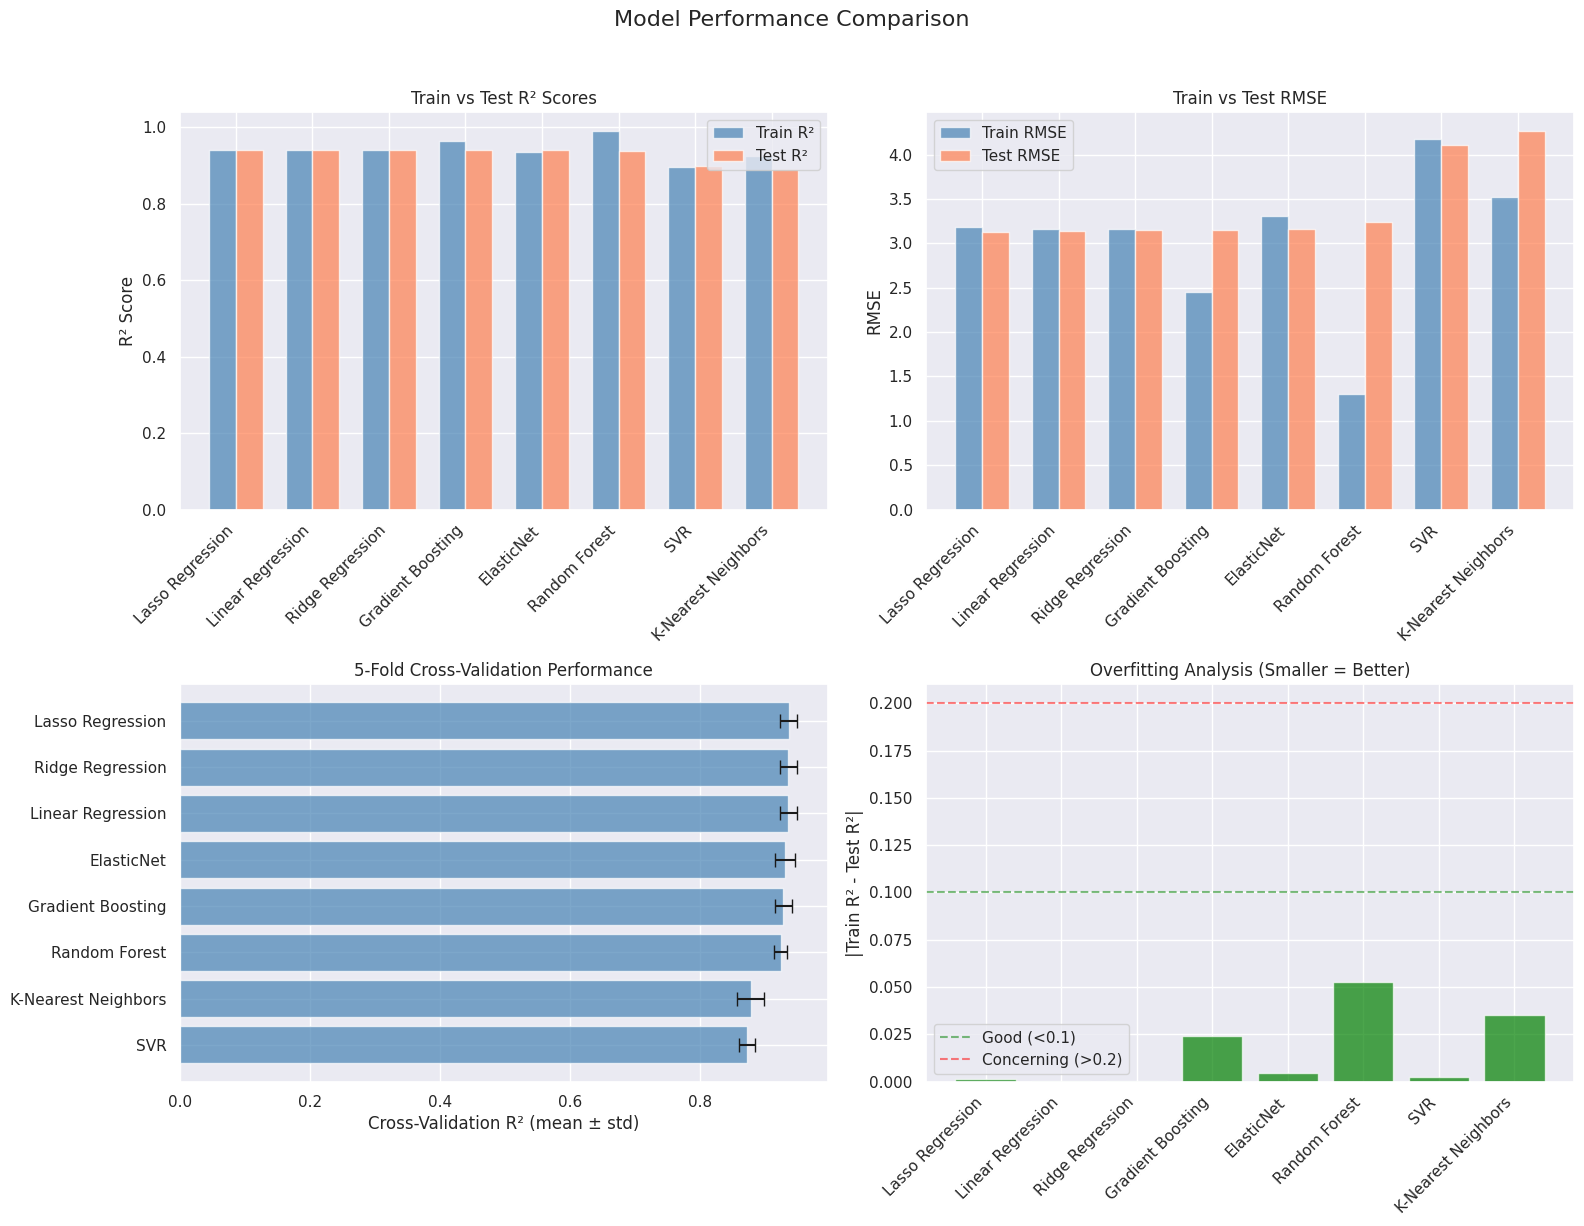



3. DETAILED CROSS-VALIDATION ANALYSIS


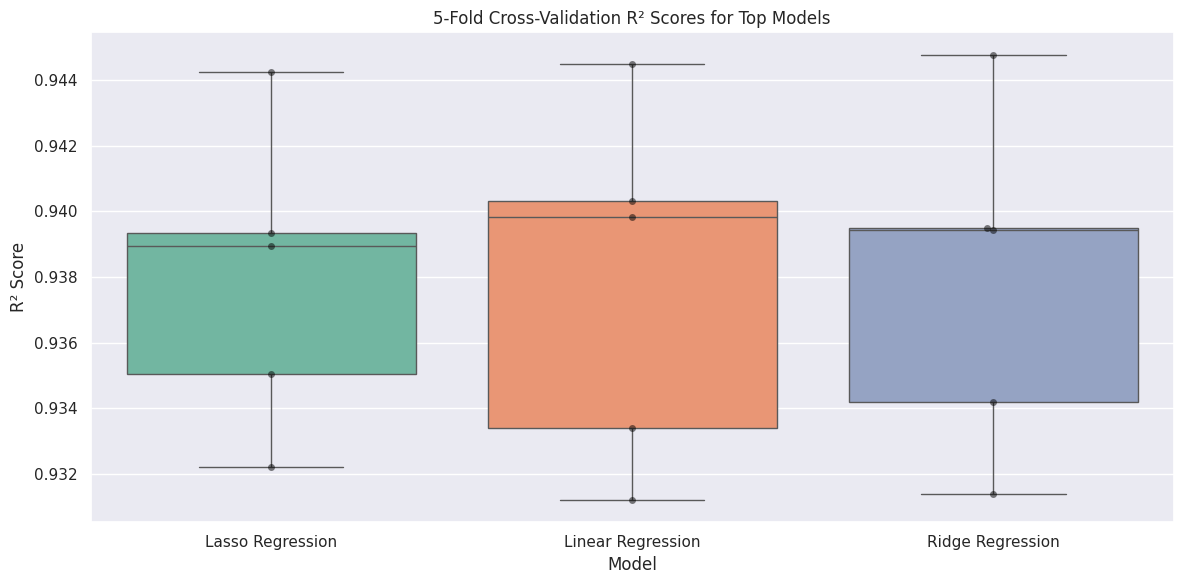


Detailed CV Statistics:

Lasso Regression:
  R² Scores per Fold: ['0.9350', '0.9443', '0.9389', '0.9322', '0.9394']
  Mean R²: 0.9380
  Std R²:  0.0041
  Min R²:  0.9322
  Max R²:  0.9443

Linear Regression:
  R² Scores per Fold: ['0.9334', '0.9445', '0.9403', '0.9312', '0.9398']
  Mean R²: 0.9378
  Std R²:  0.0049
  Min R²:  0.9312
  Max R²:  0.9445

Ridge Regression:
  R² Scores per Fold: ['0.9342', '0.9448', '0.9395', '0.9314', '0.9394']
  Mean R²: 0.9379
  Std R²:  0.0047
  Min R²:  0.9314
  Max R²:  0.9448


4. HYPERPARAMETER TUNING
Best model: Lasso Regression
Base Test R²: 0.9412

--- Tuning Gradient Boosting ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 50}
Best CV R²: 0.9309

--- Tuning Random Forest ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'mi

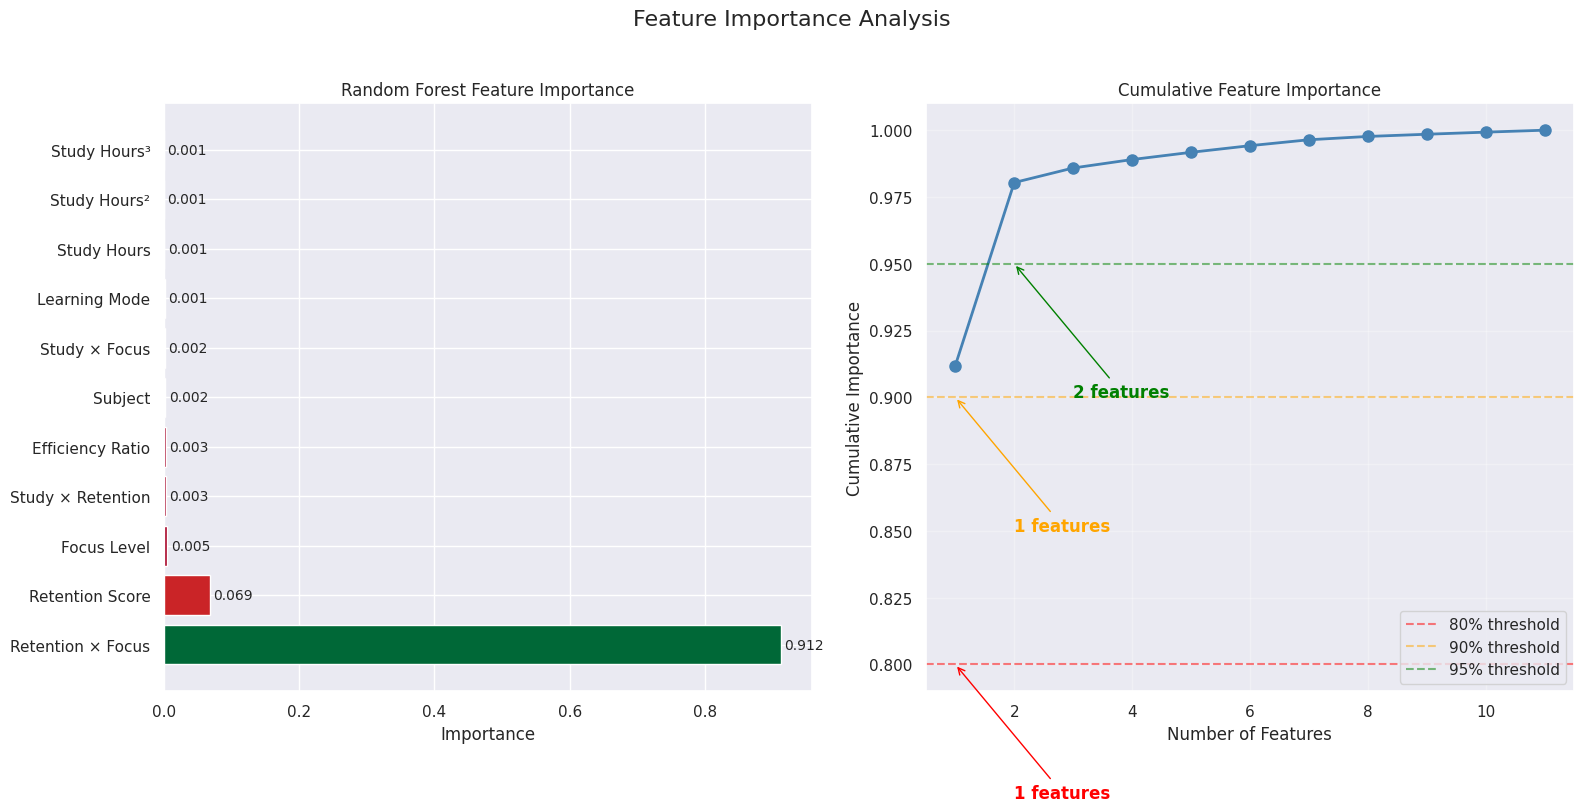


Feature Importance Ranking:
Rank  Feature                             Importance   Cumulative  
-----------------------------------------------------------------
1     Retention × Focus                   0.9119       0.9119      
2     Retention Score                     0.0685       0.9804      
3     Focus Level                         0.0055       0.9858      
4     Study × Retention                   0.0032       0.9890      
5     Efficiency Ratio                    0.0027       0.9917      
6     Subject                             0.0025       0.9942      
7     Study × Focus                       0.0022       0.9964      
8     Learning Mode                       0.0012       0.9977      
9     Study Hours                         0.0008       0.9985      
10    Study Hours²                        0.0008       0.9993      
11    Study Hours³                        0.0007       1.0000      


6. FINAL MODEL EVALUATION

Final Model: Gradient Boosting (Tuned)
---------------------

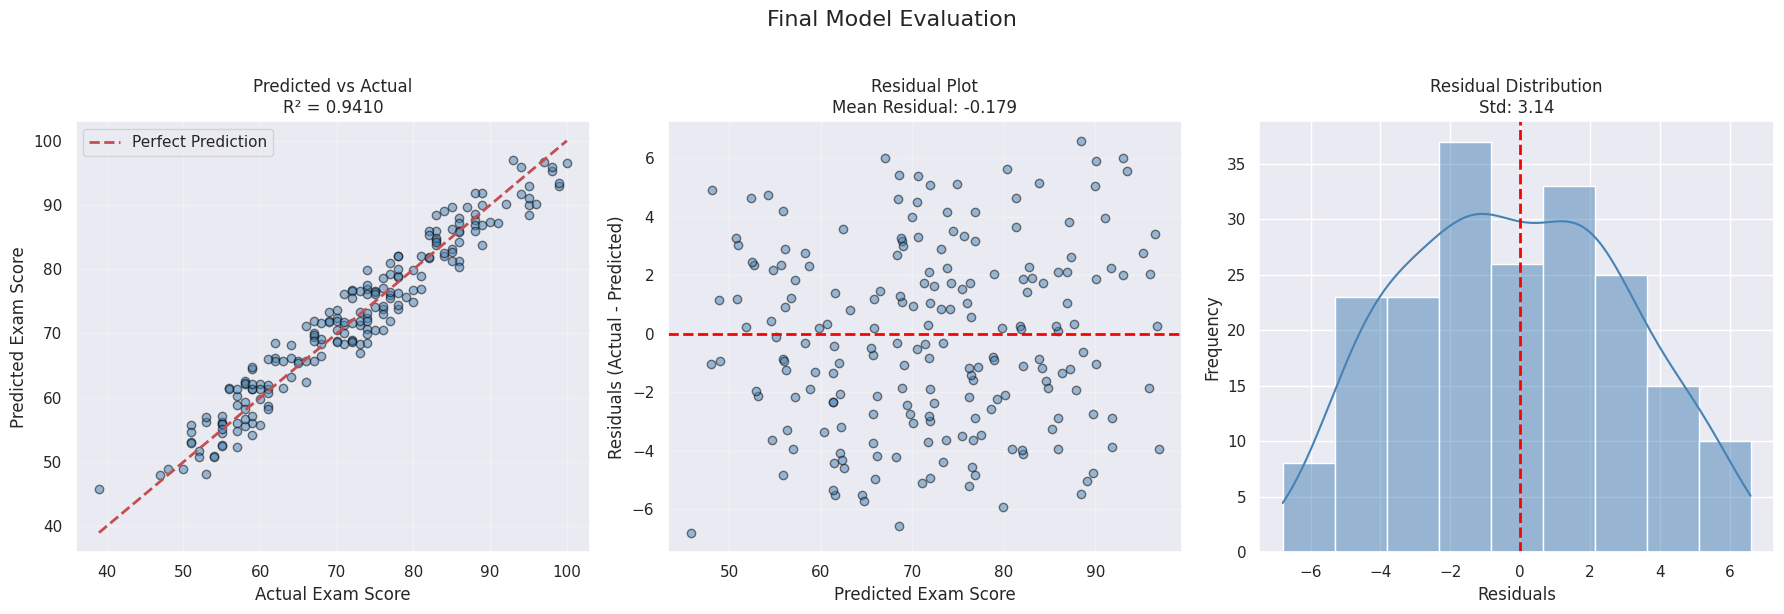



7. LEARNING CURVES


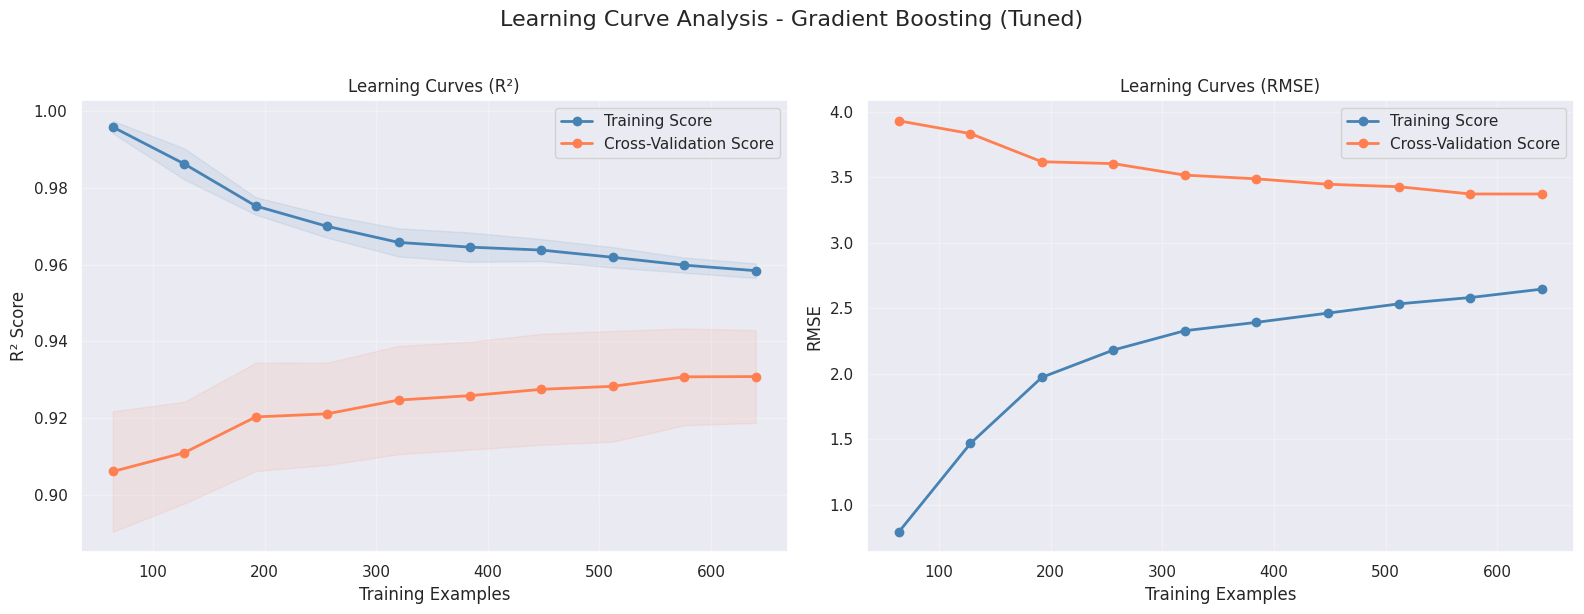



8. MODEL INTERPRETATION & INSIGHTS


9. SUMMARY & RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════════════╗
║                    ML ANALYSIS SUMMARY                               ║
╠══════════════════════════════════════════════════════════════════════╣
║ Best Model: Gradient Boosting (Tuned)                ║
║ Test R² Score:    0.9410                                      ║
║ Test RMSE:        3.1355                                      ║
║ Test MAE:         2.6511                                      ║
║                                                                      ║
║ Top 3 Most Important Features:                                       ║
║   1. Retention × Focus                   (0.912)     ║
║   2. Retention Score                     (0.069)     ║
║   3. Focus Level                         (0.005)     ║
║                                                                      ║
║ Key Insights:                                                    

In [26]:
# ## Machine Learning Analysis

# This section builds a complete ML pipeline to predict Exam_Score
# based on learning patterns. We'll:
# 1. Prepare data with proper encoding
# 2. Try multiple algorithms
# 3. Evaluate with cross-validation
# 4. Tune hyperparameters
# 5. Analyze feature importance
# 6. Build an ensemble model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Ensure data is loaded
try:
    df.head()
    if 'Study_Hours_Squared' not in df.columns:
        # Create engineered features from previous section
        df['Study_Hours_Squared'] = df['Study_Hours'] ** 2
        df['Study_Hours_Cubed'] = df['Study_Hours'] ** 3
        df['Study_Retention_Interaction'] = df['Study_Hours'] * df['Retention_Score']
        df['Study_Focus_Interaction'] = df['Study_Hours'] * df['Focus_Level']
        df['Retention_Focus_Interaction'] = df['Retention_Score'] * df['Focus_Level']
        df['Efficiency_Ratio'] = df['Retention_Score'] / df['Study_Hours']
        print("Engineered features created successfully!")
except NameError:
    print("DataFrame 'df' not found. Please run the previous cells to load the data.")

print("=" * 80)
print("MACHINE LEARNING ANALYSIS")
print("=" * 80)

# =============================================================================
# 1. DATA PREPARATION
# =============================================================================
print("\n\n1. DATA PREPARATION")
print("=" * 80)

# Create a copy for ML
df_ml = df.copy()

# Encode categorical variables
le = LabelEncoder()
df_ml['Learning_Mode_Encoded'] = le.fit_transform(df_ml['Learning_Mode'])
df_ml['Subject_Encoded'] = le.fit_transform(df_ml['Subject'])

# Create engineered features
df_ml['Study_Hours_Squared'] = df_ml['Study_Hours'] ** 2
df_ml['Study_Hours_Cubed'] = df_ml['Study_Hours'] ** 3
df_ml['Study_Retention_Interaction'] = df_ml['Study_Hours'] * df_ml['Retention_Score']
df_ml['Study_Focus_Interaction'] = df_ml['Study_Hours'] * df_ml['Focus_Level']
df_ml['Retention_Focus_Interaction'] = df_ml['Retention_Score'] * df_ml['Focus_Level']
df_ml['Efficiency_Ratio'] = df_ml['Retention_Score'] / df_ml['Study_Hours']

# Define features and target
feature_cols = [
    'Learning_Mode_Encoded', 'Subject_Encoded',
    'Study_Hours', 'Retention_Score', 'Focus_Level',
    'Study_Hours_Squared', 'Study_Hours_Cubed',
    'Study_Retention_Interaction', 'Study_Focus_Interaction',
    'Retention_Focus_Interaction', 'Efficiency_Ratio'
]

target_col = 'Exam_Score'

X = df_ml[feature_cols]
y = df_ml[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nFeatures used:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

# =============================================================================
# 2. MODEL TRAINING & COMPARISON
# =============================================================================
print("\n\n2. MODEL TRAINING & COMPARISON")
print("=" * 80)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf', C=1.0)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std()
    })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)

# Display results
print("\nModel Performance Comparison (sorted by Test R²):")
print(results_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Train vs Test R²
ax = axes[0, 0]
x_pos = np.arange(len(results_df))
width = 0.35
ax.bar(x_pos - width/2, results_df['Train R²'], width, label='Train R²', color='steelblue', alpha=0.7)
ax.bar(x_pos + width/2, results_df['Test R²'], width, label='Test R²', color='coral', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Train vs Test R² Scores')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 2. Train vs Test RMSE
ax = axes[0, 1]
ax.bar(x_pos - width/2, results_df['Train RMSE'], width, label='Train RMSE', color='steelblue', alpha=0.7)
ax.bar(x_pos + width/2, results_df['Test RMSE'], width, label='Test RMSE', color='coral', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('RMSE')
ax.set_title('Train vs Test RMSE')
ax.legend()

# 3. Cross-Validation R²
ax = axes[1, 0]
sorted_by_cv = results_df.sort_values('CV R² (mean)')
bars = ax.barh(sorted_by_cv['Model'], sorted_by_cv['CV R² (mean)'],
               xerr=sorted_by_cv['CV R² (std)'],
               color='steelblue', alpha=0.7, capsize=5)
ax.set_xlabel('Cross-Validation R² (mean ± std)')
ax.set_title('5-Fold Cross-Validation Performance')

# 4. Overfitting Analysis (Train R² - Test R²)
ax = axes[1, 1]
results_df['Overfitting Gap'] = results_df['Train R²'] - results_df['Test R²']
colors = ['green' if gap < 0.1 else 'orange' if gap < 0.2 else 'red'
          for gap in results_df['Overfitting Gap']]
bars = ax.bar(range(len(results_df)), results_df['Overfitting Gap'].abs(), color=colors, alpha=0.7)
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('|Train R² - Test R²|')
ax.set_title('Overfitting Analysis (Smaller = Better)')
ax.axhline(y=0.1, color='green', linestyle='--', label='Good (<0.1)', alpha=0.5)
ax.axhline(y=0.2, color='red', linestyle='--', label='Concerning (>0.2)', alpha=0.5)
ax.legend()

plt.suptitle('Model Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. CROSS-VALIDATION DETAILED ANALYSIS
# =============================================================================
print("\n\n3. DETAILED CROSS-VALIDATION ANALYSIS")
print("=" * 80)

# Detailed CV for best models
top_models = results_df.head(3)['Model'].tolist()

cv_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))

for model_name in top_models:
    model = models[model_name]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    cv_rmse_scores = np.sqrt(-cross_val_score(model, X_train_scaled, y_train,
                                               cv=kf, scoring='neg_mean_squared_error'))
    cv_results[model_name] = {
        'R² Scores': cv_scores,
        'RMSE Scores': cv_rmse_scores
    }

# Boxplot of CV scores
cv_data = []
for model_name in top_models:
    for score in cv_results[model_name]['R² Scores']:
        cv_data.append({'Model': model_name, 'R² Score': score})

cv_df = pd.DataFrame(cv_data)
sns.boxplot(data=cv_df, x='Model', y='R² Score', palette='Set2', ax=ax)
sns.swarmplot(data=cv_df, x='Model', y='R² Score', color='black', alpha=0.5, size=5, ax=ax)
ax.set_title('5-Fold Cross-Validation R² Scores for Top Models')
ax.set_ylabel('R² Score')
plt.tight_layout()
plt.show()

print("\nDetailed CV Statistics:")
for model_name in top_models:
    r2_scores = cv_results[model_name]['R² Scores']
    print(f"\n{model_name}:")
    print(f"  R² Scores per Fold: {[f'{s:.4f}' for s in r2_scores]}")
    print(f"  Mean R²: {r2_scores.mean():.4f}")
    print(f"  Std R²:  {r2_scores.std():.4f}")
    print(f"  Min R²:  {r2_scores.min():.4f}")
    print(f"  Max R²:  {r2_scores.max():.4f}")

# =============================================================================
# 4. HYPERPARAMETER TUNING (Best Model)
# =============================================================================
print("\n\n4. HYPERPARAMETER TUNING")
print("=" * 80)

# Find the best model
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")
print(f"Base Test R²: {results_df.iloc[0]['Test R²']:.4f}")

# Hyperparameter tuning for Gradient Boosting
print("\n--- Tuning Gradient Boosting ---")
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_split': [2, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=5, scoring='r2',
                        verbose=1, n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)

print(f"\nBest Gradient Boosting Parameters: {gb_grid.best_params_}")
print(f"Best CV R²: {gb_grid.best_score_:.4f}")

# Hyperparameter tuning for Random Forest
print("\n--- Tuning Random Forest ---")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=5, scoring='r2',
                        verbose=1, n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best CV R²: {rf_grid.best_score_:.4f}")

# =============================================================================
# 5. FEATURE IMPORTANCE ANALYSIS
# =============================================================================
print("\n\n5. FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Train final best model
best_rf = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
best_rf.fit(X_train_scaled, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Create readable feature names
feature_name_map = {
    'Learning_Mode_Encoded': 'Learning Mode',
    'Subject_Encoded': 'Subject',
    'Study_Hours': 'Study Hours',
    'Retention_Score': 'Retention Score',
    'Focus_Level': 'Focus Level',
    'Study_Hours_Squared': 'Study Hours²',
    'Study_Hours_Cubed': 'Study Hours³',
    'Study_Retention_Interaction': 'Study × Retention',
    'Study_Focus_Interaction': 'Study × Focus',
    'Retention_Focus_Interaction': 'Retention × Focus',
    'Efficiency_Ratio': 'Efficiency Ratio'
}
feature_importance['Feature_Name'] = feature_importance['Feature'].map(feature_name_map)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar plot
ax = axes[0]
colors = plt.cm.RdYlGn(feature_importance['Importance'] / feature_importance['Importance'].max())
bars = ax.barh(range(len(feature_importance)), feature_importance['Importance'],
               color=colors)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['Feature_Name'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Cumulative importance
ax = axes[1]
cumulative_importance = np.cumsum(feature_importance['Importance'])
ax.plot(range(1, len(cumulative_importance) + 1), cumulative_importance,
        marker='o', color='steelblue', linewidth=2, markersize=8)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.axhline(y=0.9, color='orange', linestyle='--', alpha=0.5, label='90% threshold')
ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='95% threshold')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Cumulative Importance')
ax.set_title('Cumulative Feature Importance')
ax.legend()
ax.grid(True, alpha=0.3)

# Find features needed for 80%, 90%, 95% importance
for threshold, color in [(0.8, 'red'), (0.9, 'orange'), (0.95, 'green')]:
    n_features = np.argmax(cumulative_importance >= threshold) + 1
    ax.annotate(f'{n_features} features',
                xy=(n_features, threshold),
                xytext=(n_features + 1, threshold - 0.05),
                arrowprops=dict(arrowstyle='->', color=color),
                color=color, fontweight='bold')

plt.suptitle('Feature Importance Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(f"{'Rank':<5} {'Feature':<35} {'Importance':<12} {'Cumulative':<12}")
print("-" * 65)
cum_sum = 0
for i, row in feature_importance.iterrows():
    cum_sum += row['Importance']
    print(f"{feature_importance.index.get_loc(i)+1:<5} {row['Feature_Name']:<35} {row['Importance']:<12.4f} {cum_sum:<12.4f}")

# =============================================================================
# 6. FINAL MODEL EVALUATION
# =============================================================================
print("\n\n6. FINAL MODEL EVALUATION")
print("=" * 80)

# Use the best model from tuning
final_model = best_rf if rf_grid.best_score_ > gb_grid.best_score_ else GradientBoostingRegressor(**gb_grid.best_params_, random_state=42)
if rf_grid.best_score_ <= gb_grid.best_score_:
    final_model = GradientBoostingRegressor(**gb_grid.best_params_, random_state=42)
    final_model_name = "Gradient Boosting (Tuned)"
else:
    final_model = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
    final_model_name = "Random Forest (Tuned)"

final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)

# Calculate final metrics
final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mae = mean_absolute_error(y_test, y_pred_final)

print(f"\nFinal Model: {final_model_name}")
print("-" * 50)
print(f"Test R² Score:    {final_r2:.4f}")
print(f"Test RMSE:        {final_rmse:.4f}")
print(f"Test MAE:         {final_mae:.4f}")
print(f"Explained Variance: {final_r2 * 100:.1f}%")

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, y_pred_final, alpha=0.5, color='steelblue', edgecolors='black')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Exam Score')
ax.set_ylabel('Predicted Exam Score')
ax.set_title(f'Predicted vs Actual\nR² = {final_r2:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Residuals
ax = axes[1]
residuals = y_test - y_pred_final
ax.scatter(y_pred_final, residuals, alpha=0.5, color='steelblue', edgecolors='black')
ax.axhline(y=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Predicted Exam Score')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.set_title(f'Residual Plot\nMean Residual: {residuals.mean():.3f}')
ax.grid(True, alpha=0.3)

# 3. Residual Distribution
ax = axes[2]
sns.histplot(residuals, kde=True, ax=ax, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title(f'Residual Distribution\nStd: {residuals.std():.2f}')

plt.suptitle('Final Model Evaluation', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 7. LEARNING CURVES
# =============================================================================
print("\n\n7. LEARNING CURVES")
print("=" * 80)

from sklearn.model_selection import learning_curve

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    final_model, X_train_scaled, y_train, cv=5,
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Learning Curve
ax = axes[0]
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.1, color='steelblue')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                alpha=0.1, color='coral')
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Score', linewidth=2)
ax.plot(train_sizes, test_mean, 'o-', color='coral', label='Cross-Validation Score', linewidth=2)
ax.set_xlabel('Training Examples')
ax.set_ylabel('R² Score')
ax.set_title('Learning Curves (R²)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# RMSE Learning Curve
train_sizes_rmse, train_rmse_scores, test_rmse_scores = learning_curve(
    final_model, X_train_scaled, y_train, cv=5,
    scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42, n_jobs=-1
)

train_rmse_mean = np.sqrt(-train_rmse_scores).mean(axis=1)
test_rmse_mean = np.sqrt(-test_rmse_scores).mean(axis=1)

ax = axes[1]
ax.plot(train_sizes_rmse, train_rmse_mean, 'o-', color='steelblue',
        label='Training Score', linewidth=2)
ax.plot(train_sizes_rmse, test_rmse_mean, 'o-', color='coral',
        label='Cross-Validation Score', linewidth=2)
ax.set_xlabel('Training Examples')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curves (RMSE)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Learning Curve Analysis - {final_model_name}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 8. MODEL INTERPRETATION
# =============================================================================
print("\n\n8. MODEL INTERPRETATION & INSIGHTS")
print("=" * 80)

# For Random Forest, we can provide partial dependence plots
if 'Random' in final_model_name:
    from sklearn.inspection import partial_dependence

    # Top 3 important features
    top_features = feature_importance.head(3)['Feature'].tolist()

    fig, ax = plt.subplots(figsize=(12, 5))

    for feature in top_features:
        pdp = partial_dependence(final_model, X_train_scaled, [X.columns.get_loc(feature)],
                                 kind='average')
        ax.plot(pdp['values'][0], pdp['average'][0],
                label=feature_name_map.get(feature, feature), linewidth=2)

    ax.set_xlabel('Feature Value (Standardized)')
    ax.set_ylabel('Partial Dependence')
    ax.set_title('Partial Dependence of Top 3 Features')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =============================================================================
# 9. SUMMARY & RECOMMENDATIONS
# =============================================================================
print("\n\n9. SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print(f"""
╔════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                    ML ANALYSIS SUMMARY                                                                     ║
╠════════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║ Best Model: {final_model_name:<40}                                                                         ║
║ Test R² Score:    {final_r2:.4f}                                                                           ║
║ Test RMSE:        {final_rmse:.4f}                                                                         ║
║ Test MAE:         {final_mae:.4f}                                                                          ║
║                                                                                                            ║
║ Top 3 Most Important Features:                                                                             ║
║   1. {feature_importance.iloc[0]['Feature_Name']:<35} ({feature_importance.iloc[0]['Importance']:.3f})     ║
║   2. {feature_importance.iloc[1]['Feature_Name']:<35} ({feature_importance.iloc[1]['Importance']:.3f})     ║
║   3. {feature_importance.iloc[2]['Feature_Name']:<35} ({feature_importance.iloc[2]['Importance']:.3f})     ║
║                                                                                                            ║
║ Key Insights:                                                                                              ║
║ • The model explains {final_r2*100:.1f}% of variance in exam scores                                        ║
║ • Average prediction error is ±{final_mae:.1f} points                                                      ║
║ • {feature_importance.iloc[0]['Feature_Name']} is the strongest predictor                                  ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Machine Learning Analysis Complete!")
print("The model is ready for making predictions on new student data.")

# Thank You